In [ ]:
"""
import os
import time
import requests
import pandas as pd
from datetime import datetime, timezone, timedelta
from dateutil.relativedelta import relativedelta
from collections import deque
from threading import Lock
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# ─── CONFIG ──────────────────────────────────────────────────────────────
API_KEY      = "b5ad5bac-9f9c-4267-8655-273678512e47"
CMC_BASE     = "https://pro-api.coinmarketcap.com"
PAGE_LIMIT   = 500        # how many tokens to pull
LOWER_FACTOR = 0.00001    # >0.001% of ETH MC
UPPER_FACTOR = 0.001      # <0.1% of ETH MC
WINDOW_DAYS  = 30         # CMC Startup tier max window
OUTPUT_DIR   = "./cmc_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── RATE LIMITER ─────────────────────────────────────────────────────────
CALL_TIMES = deque()
RL_LOCK    = Lock()
MAX_CALLS  = 30
PERIOD     = 61  # seconds

def rate_limit():
    with RL_LOCK:
        now = time.time()
        # drop old timestamps
        while CALL_TIMES and CALL_TIMES[0] <= now - PERIOD:
            CALL_TIMES.popleft()
        if len(CALL_TIMES) >= MAX_CALLS:
            wait = CALL_TIMES[0] + PERIOD - now
            time.sleep(wait)
            now = time.time()
            while CALL_TIMES and CALL_TIMES[0] <= now - PERIOD:
                CALL_TIMES.popleft()
        CALL_TIMES.append(now)

# ─── TIME WINDOW ─────────────────────────────────────────────────────────
END_DT      = datetime.now(timezone.utc)
START_DT    = END_DT - relativedelta(months=24)
MAX_WINDOW  = timedelta(days=WINDOW_DAYS)

# ─── SESSION & RETRY SETUP ───────────────────────────────────────────────
session = requests.Session()
retry = Retry(
    total=5,
    status_forcelist=[500, 502, 503, 504],
    backoff_factor=1,
    respect_retry_after_header=True
)
adapter = HTTPAdapter(max_retries=retry)
session.mount("https://", adapter)
session.mount("http://", adapter)
session.headers.update({
    "Accepts":           "application/json",
    "X-CMC_PRO_API_KEY": API_KEY
})

def cmc_get(path, params):
    url = CMC_BASE + path
    backoff = 1
    while True:
        rate_limit()
        try:
            resp = session.get(url, params=params, timeout=10)
        except (requests.exceptions.ConnectionError,
                requests.exceptions.Timeout) as net_err:
            print(f"Network error ({net_err}); retrying in 10s…")
            time.sleep(10)
            continue

        if resp.status_code == 429:
            retry_after = resp.headers.get("Retry-After")
            wait = int(retry_after) if retry_after else backoff
            print(f"429 rate-limit from {path}, sleeping for {wait}s")
            time.sleep(wait)
            backoff = min(backoff * 2, 60)
            continue

        if resp.status_code != 200:
            print(f"\nERROR {resp.status_code} from {url}")
            print("Params:", params)
            print("Body  :", resp.text)

        try:
            resp.raise_for_status()
        except requests.HTTPError as http_err:
            raise

        return resp.json()

# ─── 1) Fetch ETH’s ID & market-cap ──────────────────────────────────────
eth_info = cmc_get("/v1/cryptocurrency/quotes/latest", {
    "symbol":  "ETH",
    "convert": "USD"
})
ETH_ID = eth_info["data"]["ETH"]["id"]
ETH_MC = eth_info["data"]["ETH"]["quote"]["USD"]["market_cap"]

# ─── 2) List & filter small-cap tokens ───────────────────────────────────
listing = cmc_get("/v1/cryptocurrency/listings/latest", {
    "start":   1,
    "limit":   PAGE_LIMIT,
    "convert": "USD"
})["data"]

filtered = [
    {"id": t["id"], "symbol": t["symbol"]}
    for t in listing
    if ETH_MC * LOWER_FACTOR < t["quote"]["USD"]["market_cap"] < ETH_MC * UPPER_FACTOR
]

# ─── 3) Fetch 24-month history for those tokens ───────────────────────────
token_dfs = {}
for tok in filtered:
    sym = tok["symbol"]
    print(f"Fetching history for {sym}...")
    ws = START_DT
    pieces = []
    while ws < END_DT:
        we = min(ws + MAX_WINDOW, END_DT)
        params = {
            "id":         tok["id"],
            "time_start": ws.strftime("%Y-%m-%d"),
            "time_end":   we.strftime("%Y-%m-%d"),
            "interval":   "daily",
            "convert":    "USD"
        }
        try:
            data   = cmc_get("/v1/cryptocurrency/ohlcv/historical", params)
            quotes = data.get("data", {}).get("quotes", [])
        except requests.HTTPError as e:
            code = e.response.status_code if e.response else "N/A"
            print(f" → Skipping {sym} slice {ws.date()}–{we.date()} (HTTP {code})")
            ws = we
            continue

        if quotes:
            df = pd.DataFrame([{
                "date":   q["time_open"][:10],
                "close":  q["quote"]["USD"]["close"],
                "volume": q["quote"]["USD"]["volume"]
            } for q in quotes]).set_index("date")
            pieces.append(df)
        ws = we

    if pieces:
        full = pd.concat(pieces).drop_duplicates().sort_index()
        full.index = pd.to_datetime(full.index)
        token_dfs[sym] = full

# ─── 4) Save tokens historical & summary CSVs ────────────────────────────
dates = pd.date_range(START_DT.strftime("%Y-%m-%d"), END_DT.strftime("%Y-%m-%d"), freq="D")
master = pd.DataFrame(index=dates)
for sym, df in token_dfs.items():
    reindexed = df.reindex(dates)
    master[f"{sym}_close"]  = reindexed["close"]
    master[f"{sym}_volume"] = reindexed["volume"]

master.to_csv(os.path.join(OUTPUT_DIR, "data/all_tokens_24mo_daily.csv"))
print("→ Written all_tokens_24mo_daily.csv")

# summary
ids_csv = ",".join(str(t["id"]) for t in filtered)
quotes = cmc_get("/v1/cryptocurrency/quotes/latest", {"id": ids_csv, "convert": "USD"})["data"]
rows = [{
    "symbol":         info["symbol"],
    "circulating_supply": info.get("circulating_supply"),
    "price_usd":      info["quote"]["USD"]["price"],
    "market_cap_usd": info["quote"]["USD"]["market_cap"]
} for info in quotes.values()]

pd.DataFrame(rows).set_index("symbol").to_csv(os.path.join(OUTPUT_DIR, "data/token_summary.csv"))
print("→ Written token_summary.csv")

# ─── 5) Fetch & save ETH historical & summary CSVs ────────────────────────
print("Fetching ETH history...")
slices = []
ws = START_DT
while ws < END_DT:
    we = min(ws + MAX_WINDOW, END_DT)
    params = {
        "id":         ETH_ID,
        "time_start": ws.strftime("%Y-%m-%d"),
        "time_end":   we.strftime("%Y-%m-%d"),
        "interval":   "daily",
        "convert":    "USD"
    }
    try:
        data   = cmc_get("/v1/cryptocurrency/ohlcv/historical", params)
        quotes = data.get("data", {}).get("quotes", [])
    except requests.HTTPError as e:
        code = e.response.status_code if e.response else "N/A"
        print(f" → Skipping ETH slice {ws.date()}–{we.date()} (HTTP {code})")
        ws = we
        continue

    if quotes:
        df = pd.DataFrame([{
            "date":   q["time_open"][:10],
            "close":  q["quote"]["USD"]["close"],
            "volume": q["quote"]["USD"]["volume"]
        } for q in quotes]).set_index("date")
        slices.append(df)
    ws = we

eth_hist = pd.concat(slices).drop_duplicates().sort_index()
eth_hist.index = pd.to_datetime(eth_hist.index)
eth_hist.to_csv(os.path.join(OUTPUT_DIR, "data/eth_ohlcv.csv"))
print("→ Written eth_ohlcv.csv")

eth_summary = {
    "symbol":         eth_info["data"]["ETH"]["symbol"],
    "circulating_supply": eth_info["data"]["ETH"].get("circulating_supply"),
    "price_usd":      eth_info["data"]["ETH"]["quote"]["USD"]["price"],
    "market_cap_usd": eth_info["data"]["ETH"]["quote"]["USD"]["market_cap"]
}
pd.DataFrame([eth_summary]).set_index("symbol") \
  .to_csv(os.path.join(OUTPUT_DIR, "data/eth_summary.csv"))
print("→ Written eth_summary.csv")
"""

'\nimport os\nimport time\nimport requests\nimport pandas as pd\nfrom datetime import datetime, timezone, timedelta\nfrom dateutil.relativedelta import relativedelta\nfrom collections import deque\nfrom threading import Lock\nfrom requests.adapters import HTTPAdapter\nfrom urllib3.util.retry import Retry\n\n# ─── CONFIG ──────────────────────────────────────────────────────────────\nAPI_KEY      = "b5ad5bac-9f9c-4267-8655-273678512e47"\nCMC_BASE     = "https://pro-api.coinmarketcap.com"\nPAGE_LIMIT   = 500        # how many tokens to pull\nLOWER_FACTOR = 0.00001    # >0.001% of ETH MC\nUPPER_FACTOR = 0.001      # <0.1% of ETH MC\nWINDOW_DAYS  = 30         # CMC Startup tier max window\nOUTPUT_DIR   = "./cmc_output"\nos.makedirs(OUTPUT_DIR, exist_ok=True)\n\n# ─── RATE LIMITER ─────────────────────────────────────────────────────────\nCALL_TIMES = deque()\nRL_LOCK    = Lock()\nMAX_CALLS  = 30\nPERIOD     = 61  # seconds\n\ndef rate_limit():\n    with RL_LOCK:\n        now = time.time()\

In [25]:
import pandas as pd
data = pd.read_csv('data/all_tokens_24mo_daily.csv')
data = data.iloc[1:-1]

In [26]:
print(data.isnull().any().sum())
print(len(data.columns.tolist()))
data = data.set_index(data.columns[0])
data.head()

274
639


,CVX_close,CVX_volume,KSM_close,KSM_volume,NXPC_close,NXPC_volume,CTC_close,CTC_volume,MINA_close,MINA_volume,...,0x0_close,0x0_volume,KUJI_close,KUJI_volume,FUEL_close,FUEL_volume,vBUSD_close,vBUSD_volume,X_close,X_volume
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
2023-05-30,4.399442,6749959.46,26.176435,5794834.37,NaN,NaN,0.307947,20133150.73,0.566569,6835242.73,...,0.047829,1369223.65,0.936778,380381.54,NaN,NaN,0.022112,0.0,NaN,NaN
2023-05-31,4.183987,5738638.03,26.478534,7400830.47,NaN,NaN,0.308439,20476451.69,0.540227,10618245.81,...,0.051749,2687326.11,0.953731,462687.33,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-01,4.197695,5205128.29,26.268156,10083300.88,NaN,NaN,0.304901,17851170.72,0.532843,7631518.87,...,0.055761,1316748.61,1.024203,813613.09,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-02,4.262017,6109653.42,26.611021,10874642.58,NaN,NaN,0.306256,19609414.14,0.544120,6042216.88,...,0.047468,1079759.27,1.068798,611845.10,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-03,4.269994,3926502.22,27.307275,6670866.47,NaN,NaN,0.304753,18873052.87,0.546261,4469109.61,...,0.037496,2072020.37,0.963442,605176.89,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
print(len(data.columns.tolist()))
data.index.rename('Date', inplace=True)
data.head()

638


,CVX_close,CVX_volume,KSM_close,KSM_volume,NXPC_close,NXPC_volume,CTC_close,CTC_volume,MINA_close,MINA_volume,...,0x0_close,0x0_volume,KUJI_close,KUJI_volume,FUEL_close,FUEL_volume,vBUSD_close,vBUSD_volume,X_close,X_volume
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-30,4.399442,6749959.46,26.176435,5794834.37,NaN,NaN,0.307947,20133150.73,0.566569,6835242.73,...,0.047829,1369223.65,0.936778,380381.54,NaN,NaN,0.022112,0.0,NaN,NaN
2023-05-31,4.183987,5738638.03,26.478534,7400830.47,NaN,NaN,0.308439,20476451.69,0.540227,10618245.81,...,0.051749,2687326.11,0.953731,462687.33,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-01,4.197695,5205128.29,26.268156,10083300.88,NaN,NaN,0.304901,17851170.72,0.532843,7631518.87,...,0.055761,1316748.61,1.024203,813613.09,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-02,4.262017,6109653.42,26.611021,10874642.58,NaN,NaN,0.306256,19609414.14,0.544120,6042216.88,...,0.047468,1079759.27,1.068798,611845.10,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-03,4.269994,3926502.22,27.307275,6670866.47,NaN,NaN,0.304753,18873052.87,0.546261,4469109.61,...,0.037496,2072020.37,0.963442,605176.89,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
data = data.dropna(axis=1, how='any')
print(len(data.columns))
data.head()

364


,CTC_close,CTC_volume,MINA_close,MINA_volume,DASH_close,DASH_volume,FRAX_close,FRAX_volume,SFP_close,SFP_volume,...,OMI_close,OMI_volume,GEOD_close,GEOD_volume,EDU_close,EDU_volume,0x0_close,0x0_volume,KUJI_close,KUJI_volume
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-30,0.307947,20133150.73,0.566569,6835242.73,43.862540,48880725.55,0.999477,10355362.99,0.412047,4738170.49,...,0.000611,579605.22,0.024957,2243.30,1.148181,1.345847e+08,0.047829,1369223.65,0.936778,380381.54
2023-05-31,0.308439,20476451.69,0.540227,10618245.81,41.865772,59012888.43,0.999474,5207849.88,0.411464,5613163.01,...,0.000618,707003.25,0.024280,2809.64,1.162424,9.176114e+07,0.051749,2687326.11,0.953731,462687.33
2023-06-01,0.304901,17851170.72,0.532843,7631518.87,41.873003,56703263.06,0.999307,3293503.58,0.407362,8354622.17,...,0.000598,586363.36,0.024244,2159.42,1.117054,5.196256e+07,0.055761,1316748.61,1.024203,813613.09
2023-06-02,0.306256,19609414.14,0.544120,6042216.88,42.726666,52836782.21,0.999344,6709756.27,0.406233,5889665.20,...,0.000636,597210.98,0.023709,690.38,1.139777,4.781171e+07,0.047468,1079759.27,1.068798,611845.10
2023-06-03,0.304753,18873052.87,0.546261,4469109.61,42.630537,48672187.36,0.995996,3921671.40,0.408292,3565805.82,...,0.000656,674675.88,0.023977,911.22,1.114714,2.807642e+07,0.037496,2072020.37,0.963442,605176.89


In [29]:
close_names = []
vol_names = []
col_names = data.columns.tolist()
for name in col_names:
    if "_close" in name:
        close_names.append(name)
    else: 
        vol_names.append(name)

In [30]:
data_prices = data[close_names]
vol_names = data[vol_names]
vol_names.head()

,CTC_volume,MINA_volume,DASH_volume,FRAX_volume,SFP_volume,BabyDoge_volume,SNX_volume,TFUEL_volume,DCR_volume,GLM_volume,...,KNC_volume,CTSI_volume,BTRST_volume,SCRT_volume,lisUSD_volume,OMI_volume,GEOD_volume,EDU_volume,0x0_volume,KUJI_volume
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-30,20133150.73,6835242.73,48880725.55,10355362.99,4738170.49,2590384.21,20452459.37,2720683.01,795321.26,1997725.96,...,4937621.93,52878949.23,534480.78,1477752.79,115079.57,579605.22,2243.30,1.345847e+08,1369223.65,380381.54
2023-05-31,20476451.69,10618245.81,59012888.43,5207849.88,5613163.01,2775479.04,23197330.37,2470171.60,1590810.15,1892681.67,...,4739781.71,18896948.52,548700.11,2576695.10,209686.85,707003.25,2809.64,9.176114e+07,2687326.11,462687.33
2023-06-01,17851170.72,7631518.87,56703263.06,3293503.58,8354622.17,4090556.54,21500733.54,11653807.64,1141237.81,1762721.16,...,3285373.79,10116202.57,464872.71,1929650.52,282365.67,586363.36,2159.42,5.196256e+07,1316748.61,813613.09
2023-06-02,19609414.14,6042216.88,52836782.21,6709756.27,5889665.20,3906490.11,18326389.99,2635260.00,1033673.67,1824988.98,...,3230720.85,12574464.50,503330.21,2174894.97,284328.24,597210.98,690.38,4.781171e+07,1079759.27,611845.10
2023-06-03,18873052.87,4469109.61,48672187.36,3921671.40,3565805.82,2990084.20,15746575.05,1881796.56,1138004.71,1512597.16,...,2877404.79,7921896.84,428194.22,2150178.18,320188.42,674675.88,911.22,2.807642e+07,2072020.37,605176.89


In [31]:
print(data_prices.columns.tolist())

['CTC_close', 'MINA_close', 'DASH_close', 'FRAX_close', 'SFP_close', 'BabyDoge_close', 'SNX_close', 'TFUEL_close', 'DCR_close', 'GLM_close', 'MX_close', 'ZIL_close', 'BLUR_close', 'ROSE_close', 'CKB_close', 'TRAC_close', 'QTUM_close', 'ORDI_close', 'LPT_close', 'MASK_close', 'ASTR_close', 'ZRX_close', 'VTHO_close', 'ACH_close', 'BAT_close', 'CHEEL_close', 'CHEX_close', 'SNEK_close', 'BORG_close', 'KOGE_close', 'IOTX_close', 'CELO_close', 'GAS_close', 'EURC_close', 'ONE_close', 'ID_close', 'SUSHI_close', 'CSPR_close', 'HOT_close', 'SC_close', 'YFI_close', 'RVN_close', 'ETHW_close', 'COW_close', 'ANKR_close', 'GOMINING_close', 'XCH_close', 'DGB_close', 'T_close', 'WOO_close', 'ELF_close', 'EUL_close', 'ORCA_close', 'KDA_close', 'OSMO_close', 'GMT_close', 'SNT_close', 'GMX_close', 'ENJ_close', 'XYO_close', 'POLYX_close', 'ZIG_close', 'ZEN_close', 'COTI_close', 'WEMIX_close', 'SKL_close', 'LCX_close', 'WAVES_close', 'CVC_close', 'EURS_close', 'SWFTC_close', 'LUNA_close', 'HIVE_close', 'RLB

In [32]:
import numpy as np
returns = pd.DataFrame()
volumes = pd.DataFrame()
for asset in data_prices.columns.tolist():
    asset_name = asset.split('_')[0]
    if asset_name not in ['FRAX', 'USDP', 'USTC', 'lisUSD', 'EURC', 'EURS', 'ETHW', 'BITCOIN']:
        returns[f'{asset_name}_returns'] = np.log(data_prices[asset] / data_prices[asset].shift(1))
        volumes[f'{asset_name}_volumes'] = vol_names[f'{asset_name}_volume']

/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/1618412672.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns[f'{asset_name}_returns'] = np.log(data_prices[asset] / data_prices[asset].shift(1))
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/1618412672.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  volumes[f'{asset_name}_volumes'] = vol_names[f'{asset_name}_volume']
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/1618412672.py:7: PerformanceWarning: DataFrame is highl

In [33]:
volumes = volumes.iloc[1:]

In [34]:
volumes.head()

,CTC_volumes,MINA_volumes,DASH_volumes,SFP_volumes,BabyDoge_volumes,SNX_volumes,TFUEL_volumes,DCR_volumes,GLM_volumes,MX_volumes,...,MTL_volumes,KNC_volumes,CTSI_volumes,BTRST_volumes,SCRT_volumes,OMI_volumes,GEOD_volumes,EDU_volumes,0x0_volumes,KUJI_volumes
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-31,20476451.69,10618245.81,59012888.43,5613163.01,2775479.04,23197330.37,2470171.60,1590810.15,1892681.67,4180464.55,...,7432329.91,4739781.71,18896948.52,548700.11,2576695.10,707003.25,2809.64,91761141.74,2687326.11,462687.33
2023-06-01,17851170.72,7631518.87,56703263.06,8354622.17,4090556.54,21500733.54,11653807.64,1141237.81,1762721.16,7118994.77,...,5286299.63,3285373.79,10116202.57,464872.71,1929650.52,586363.36,2159.42,51962559.84,1316748.61,813613.09
2023-06-02,19609414.14,6042216.88,52836782.21,5889665.20,3906490.11,18326389.99,2635260.00,1033673.67,1824988.98,4141131.28,...,5392869.07,3230720.85,12574464.50,503330.21,2174894.97,597210.98,690.38,47811714.82,1079759.27,611845.10
2023-06-03,18873052.87,4469109.61,48672187.36,3565805.82,2990084.20,15746575.05,1881796.56,1138004.71,1512597.16,8114075.04,...,48410926.97,2877404.79,7921896.84,428194.22,2150178.18,674675.88,911.22,28076418.58,2072020.37,605176.89
2023-06-04,19589289.05,6051590.28,48808783.13,3240633.09,2602060.90,14358864.48,2950066.67,884398.10,1622213.07,5395844.50,...,88882877.25,2621863.56,9338548.87,445417.28,979233.64,738505.30,1062.71,30978862.91,762761.67,316994.11


In [35]:
log_returns = returns.iloc[1:]
log_returns.head()

,CTC_returns,MINA_returns,DASH_returns,SFP_returns,BabyDoge_returns,SNX_returns,TFUEL_returns,DCR_returns,GLM_returns,MX_returns,...,MTL_returns,KNC_returns,CTSI_returns,BTRST_returns,SCRT_returns,OMI_returns,GEOD_returns,EDU_returns,0x0_returns,KUJI_returns
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-31,0.001598,-0.047611,-0.046592,-0.001417,-0.021767,-0.032977,-0.028345,-0.048030,-0.019603,0.026648,...,-0.048152,-0.032057,-0.045055,-0.016248,-0.109061,0.011238,-0.027480,0.012328,0.078777,0.017936
2023-06-01,-0.011538,-0.013763,0.000173,-0.010017,-0.037707,-0.000262,0.006738,-0.016666,-0.009906,0.017904,...,-0.020801,-0.000305,-0.009426,-0.001038,-0.011172,-0.033331,-0.001504,-0.039813,0.074677,0.071288
2023-06-02,0.004433,0.020943,0.020182,-0.002777,-0.010424,0.023523,0.014468,0.002995,0.013575,0.049383,...,0.019426,0.027148,0.021643,0.000108,0.008023,0.062389,-0.022298,0.020138,-0.161018,0.042620
2023-06-03,-0.004920,0.003928,-0.002252,0.005055,-0.008754,-0.011759,-0.002995,-0.006855,0.003568,0.015427,...,0.098211,-0.007559,-0.015206,-0.007805,0.013458,0.029918,0.011227,-0.022235,-0.235841,-0.103777
2023-06-04,-0.001090,-0.002065,0.000101,-0.002562,-0.018066,0.001833,0.010451,-0.002123,0.003354,-0.043010,...,0.080230,0.012538,0.004882,0.006107,-0.026127,-0.022918,-0.022158,-0.002495,0.013223,0.039397


In [36]:
log_returns.tail()

,CTC_returns,MINA_returns,DASH_returns,SFP_returns,BabyDoge_returns,SNX_returns,TFUEL_returns,DCR_returns,GLM_returns,MX_returns,...,MTL_returns,KNC_returns,CTSI_returns,BTRST_returns,SCRT_returns,OMI_returns,GEOD_returns,EDU_returns,0x0_returns,KUJI_returns
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-24,0.019470,-0.002159,-0.005366,0.036328,0.016031,0.009572,0.007701,0.031936,0.000248,-0.000116,...,-0.009487,0.005308,-0.013225,-0.018023,-0.005674,0.020046,-0.000759,-0.016702,-0.000914,-0.031074
2025-05-25,-0.003758,0.003516,0.019061,-0.013994,0.016047,-0.022422,-0.003210,-0.037979,0.009317,0.009138,...,0.007855,-0.022277,-0.002697,0.001276,-0.011274,-0.045114,-0.059627,-0.018316,-0.028354,-0.021221
2025-05-26,0.002745,-0.018078,-0.006585,0.008057,-0.028443,0.006523,-0.000119,0.030493,-0.009786,0.001686,...,-0.012922,0.002196,-0.020095,0.011187,-0.003567,-0.007094,-0.005949,0.028582,-0.083627,0.000057
2025-05-27,0.005923,0.015212,0.020031,0.014352,0.015769,0.009176,0.039880,0.027562,0.013718,0.000921,...,0.025075,0.014347,0.030896,-0.029669,0.014039,-0.036178,0.046059,0.011352,0.015956,-0.051112
2025-05-28,-0.018122,-0.007522,-0.007334,-0.015181,-0.008573,0.001712,-0.021530,-0.003556,-0.017732,-0.002381,...,-0.027032,-0.015139,-0.014835,0.004154,-0.000515,0.004846,0.000469,-0.043479,-0.087762,0.010595


In [37]:
log_returns.shape

(729, 174)

In [38]:
eth_data = pd.read_csv('data/eth_ohlcv.csv')
eth_data = eth_data.set_index(eth_data.columns[0])
eth_data.index.rename('Date', inplace=True)
eth_data.head()

,close,volume
Date,,
2023-05-30,1901.026568,5.363440e+09
2023-05-31,1874.130435,5.984513e+09
2023-06-01,1862.201451,5.640027e+09
2023-06-02,1907.256636,6.097746e+09
2023-06-03,1892.412529,3.472275e+09


In [39]:
eth_close_names = []
eth_vol_names = []
eth_col_names = eth_data.columns.tolist()
for name in eth_col_names:
    if "close" in name:
        eth_close_names.append(name)
    else: 
        eth_vol_names.append(name)

In [40]:
data_prices = eth_data[eth_close_names]
vol_names = eth_data[eth_vol_names]
data_prices.head()

,close
Date,
2023-05-30,1901.026568
2023-05-31,1874.130435
2023-06-01,1862.201451
2023-06-02,1907.256636
2023-06-03,1892.412529


In [41]:
eth_volumes = vol_names.iloc[1:]

In [42]:
eth_volumes.shape

(729, 1)

In [43]:
import numpy as np
eth_returns = pd.DataFrame()
eth_returns['ETH_returns'] = np.log(data_prices['close'] / data_prices['close'].shift(1))

In [44]:
eth_returns = eth_returns.iloc[1:]

In [45]:
eth_returns.head()

,ETH_returns
Date,
2023-05-31,-0.014249
2023-06-01,-0.006385
2023-06-02,0.023907
2023-06-03,-0.007813
2023-06-04,-0.001004


In [46]:
eth_returns.shape

(729, 1)

In [47]:
common_idx = log_returns.index.intersection(eth_returns.index)

log_returns_shared     = log_returns.loc[common_idx]
eth_log_returns_shared = eth_returns.loc[common_idx]

In [48]:
log_returns_shared.head()

,CTC_returns,MINA_returns,DASH_returns,SFP_returns,BabyDoge_returns,SNX_returns,TFUEL_returns,DCR_returns,GLM_returns,MX_returns,...,MTL_returns,KNC_returns,CTSI_returns,BTRST_returns,SCRT_returns,OMI_returns,GEOD_returns,EDU_returns,0x0_returns,KUJI_returns
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-31,0.001598,-0.047611,-0.046592,-0.001417,-0.021767,-0.032977,-0.028345,-0.048030,-0.019603,0.026648,...,-0.048152,-0.032057,-0.045055,-0.016248,-0.109061,0.011238,-0.027480,0.012328,0.078777,0.017936
2023-06-01,-0.011538,-0.013763,0.000173,-0.010017,-0.037707,-0.000262,0.006738,-0.016666,-0.009906,0.017904,...,-0.020801,-0.000305,-0.009426,-0.001038,-0.011172,-0.033331,-0.001504,-0.039813,0.074677,0.071288
2023-06-02,0.004433,0.020943,0.020182,-0.002777,-0.010424,0.023523,0.014468,0.002995,0.013575,0.049383,...,0.019426,0.027148,0.021643,0.000108,0.008023,0.062389,-0.022298,0.020138,-0.161018,0.042620
2023-06-03,-0.004920,0.003928,-0.002252,0.005055,-0.008754,-0.011759,-0.002995,-0.006855,0.003568,0.015427,...,0.098211,-0.007559,-0.015206,-0.007805,0.013458,0.029918,0.011227,-0.022235,-0.235841,-0.103777
2023-06-04,-0.001090,-0.002065,0.000101,-0.002562,-0.018066,0.001833,0.010451,-0.002123,0.003354,-0.043010,...,0.080230,0.012538,0.004882,0.006107,-0.026127,-0.022918,-0.022158,-0.002495,0.013223,0.039397


In [49]:
eth_log_returns_shared.head()

,ETH_returns
Date,
2023-05-31,-0.014249
2023-06-01,-0.006385
2023-06-02,0.023907
2023-06-03,-0.007813
2023-06-04,-0.001004


In [50]:
excess_log_returns = log_returns_shared.subtract(
    eth_log_returns_shared["ETH_returns"], 
    axis=0
)

In [51]:
excess_log_returns.head()

,CTC_returns,MINA_returns,DASH_returns,SFP_returns,BabyDoge_returns,SNX_returns,TFUEL_returns,DCR_returns,GLM_returns,MX_returns,...,MTL_returns,KNC_returns,CTSI_returns,BTRST_returns,SCRT_returns,OMI_returns,GEOD_returns,EDU_returns,0x0_returns,KUJI_returns
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-31,0.015847,-0.033361,-0.032343,0.012832,-0.007518,-0.018728,-0.014096,-0.033781,-0.005354,0.040897,...,-0.033902,-0.017808,-0.030805,-0.001998,-0.094811,0.025487,-0.013231,0.026578,0.093026,0.032185
2023-06-01,-0.005152,-0.007377,0.006558,-0.003632,-0.031321,0.006124,0.013123,-0.010281,-0.003521,0.024289,...,-0.014416,0.006081,-0.003041,0.005347,-0.004786,-0.026946,0.004881,-0.033427,0.081063,0.077673
2023-06-02,-0.019474,-0.002963,-0.003725,-0.026683,-0.034331,-0.000383,-0.009439,-0.020912,-0.010331,0.025477,...,-0.004480,0.003241,-0.002264,-0.023798,-0.015883,0.038483,-0.046204,-0.003769,-0.184924,0.018713
2023-06-03,0.002893,0.011741,0.005561,0.012868,-0.000940,-0.003946,0.004818,0.000958,0.011381,0.023240,...,0.106025,0.000255,-0.007393,0.000009,0.021272,0.037731,0.019040,-0.014422,-0.228027,-0.095964
2023-06-04,-0.000086,-0.001061,0.001105,-0.001558,-0.017062,0.002837,0.011455,-0.001120,0.004357,-0.042006,...,0.081234,0.013542,0.005886,0.007111,-0.025123,-0.021914,-0.021154,-0.001491,0.014227,0.040401


In [52]:
excess_log_returns.shape

(729, 174)

In [53]:
corr = excess_log_returns.corr()

In [54]:
print(corr.isna().sum().sum())

0


In [55]:
mask = np.eye(len(corr), dtype=bool)
corr = corr.mask(mask, 0)

In [56]:
np.all(np.diag(corr) == 0)

np.True_

In [57]:
import networkx as nx

def find_min_k_for_max_components(corr: pd.DataFrame,
                                  max_cc: int = 1,
                                  k_values: range = range(1, 50)) -> int:
    """
    Find the smallest k such that the k-NN graph built from |corr| has at most max_cc connected components.
    """
    assets = corr.index.tolist()
    for k in k_values:
        A = pd.DataFrame(0.0, index=assets, columns=assets)
        for a in assets:
            topk = corr.loc[a].abs().nlargest(k).index
            A.loc[a, topk] = corr.loc[a, topk]
        A_sym = pd.DataFrame(np.maximum(A.values, A.values.T),
                             index=assets, columns=assets)
        G = nx.from_pandas_adjacency((A_sym != 0).astype(int))
        if nx.number_connected_components(G) <= max_cc:
            return k
    raise ValueError(f"No k in {k_values} yields ≤{max_cc} components")

min_k = find_min_k_for_max_components(corr, max_cc=1, k_values=range(1, 175))
print("Minimum k with at most 1 connected component:", min_k)

Minimum k with at most 1 connected component: 2


In [58]:
def build_knn_graph(corr_df, k):
    """Return symmetrized k-NN graph on |corr_df|, with diagonal already zeroed."""
    A = pd.DataFrame(0.0, index=corr_df.index, columns=corr_df.columns)
    for u in corr_df.index:
        topk = corr_df.loc[u].abs().nlargest(k).index
        A.loc[u, topk] = corr_df.loc[u, topk]
    A = pd.DataFrame(np.maximum(A.values, A.values.T),
                     index=corr_df.index, columns=corr_df.columns)
    return A

def graph_stats(A):
    """Return (#connected components, avg node degree) for the unweighted graph."""
    G = nx.from_pandas_adjacency((A != 0).astype(int))
    return nx.number_connected_components(G), (A != 0).sum(axis=1).mean()

results = []
for k in range(2, 21):
    A_knn = build_knn_graph(corr, k)
    cc, avg_deg = graph_stats(A_knn)
    results.append((k, cc, avg_deg))

df = pd.DataFrame(results, columns=["k", "#components", "avg_degree"])
print(df.to_string(index=False))

 k  #components  avg_degree
 2            1    3.666667
 3            1    5.482759
 4            1    7.333333
 5            1    9.160920
 6            1   10.954023
 7            1   12.712644
 8            1   14.505747
 9            1   16.310345
10            1   18.068966
11            1   19.885057
12            1   21.574713
13            1   23.218391
14            1   24.839080
15            1   26.436782
16            1   28.103448
17            1   29.666667
18            1   31.149425
19            1   32.712644
20            1   34.356322


In [59]:
def build_signed_knn_sparse_corr(corr: pd.DataFrame, k_pos: int = 6, k_neg: int = 6) -> pd.DataFrame:
    """
    Build a signed k-NN sparsified correlation matrix:
    - For each node, keep its k_pos strongest positive and k_neg strongest negative correlations.
    - Symmetrize and combine into a single sparse signed-correlation DataFrame.
    """
    
    assets = corr.index
    A_plus  = pd.DataFrame(0.0, index=assets, columns=assets)
    A_minus = pd.DataFrame(0.0, index=assets, columns=assets)
    
    for u in assets:
        pos_neighbors = corr.loc[u].nlargest(k_pos).index
        neg_neighbors = corr.loc[u].nsmallest(k_neg).index
        
        A_plus.loc[u, pos_neighbors]   = corr.loc[u, pos_neighbors]
        A_minus.loc[u, neg_neighbors]  = -corr.loc[u, neg_neighbors]  
    
    A_plus  = pd.DataFrame(np.maximum(A_plus.values,  A_plus.values.T),  index=assets, columns=assets)
    A_minus = pd.DataFrame(np.maximum(A_minus.values, A_minus.values.T), index=assets, columns=assets)
    
    sparse_corr = A_plus - A_minus
    
    return sparse_corr

sparse_corr = build_signed_knn_sparse_corr(corr, k_pos=6, k_neg=6)
sparse_corr

,CTC_returns,MINA_returns,DASH_returns,SFP_returns,BabyDoge_returns,SNX_returns,TFUEL_returns,DCR_returns,GLM_returns,MX_returns,...,MTL_returns,KNC_returns,CTSI_returns,BTRST_returns,SCRT_returns,OMI_returns,GEOD_returns,EDU_returns,0x0_returns,KUJI_returns
CTC_returns,0.000000,0.0,0.318422,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0
MINA_returns,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0
DASH_returns,0.318422,0.0,0.000000,0.402253,0.0,0.0,0.0,0.484492,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0
SFP_returns,0.000000,0.0,0.402253,0.000000,0.0,0.0,0.0,0.000000,0.0,0.368043,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,-0.007379,0.0
BabyDoge_returns,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OMI_returns,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.316936,...,0.000000,0.0,0.0,0.249535,0.0,0.0,0.000000,0.0,0.000000,0.0
GEOD_returns,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.350042,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,-0.043715,0.0
EDU_returns,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0
0x0_returns,0.000000,0.0,0.000000,-0.007379,0.0,0.0,0.0,0.000000,0.0,-0.058438,...,-0.021258,0.0,0.0,-0.057121,0.0,0.0,-0.043715,0.0,0.000000,0.0


In [60]:
# Step 3: Check for isolated nodes (degree zero)
degrees = (sparse_corr != 0).sum(axis=1)
isolates = degrees[degrees == 0]

print("Isolated nodes (degree=0):")
print(isolates)

# If there are any, reconnect each isolate to its single strongest neighbor:
for node in isolates.index:
    # find the asset it correlates most strongly with (in absolute terms)
    neighbor = sparse_corr.loc[node].abs().idxmax()
    # add that edge back in both directions
    sparse_corr.loc[node, neighbor] = sparse_corr.loc[node, neighbor]
    sparse_corr.loc[neighbor, node] = sparse_corr.loc[neighbor, node]

# Recompute degrees to verify no isolates remain
degrees_after = (sparse_corr != 0).sum(axis=1)
print("\nDegrees after reconnecting isolates:")
print(degrees_after[degrees_after == 0])

Isolated nodes (degree=0):
Series([], dtype: int64)

Degrees after reconnecting isolates:
Series([], dtype: int64)


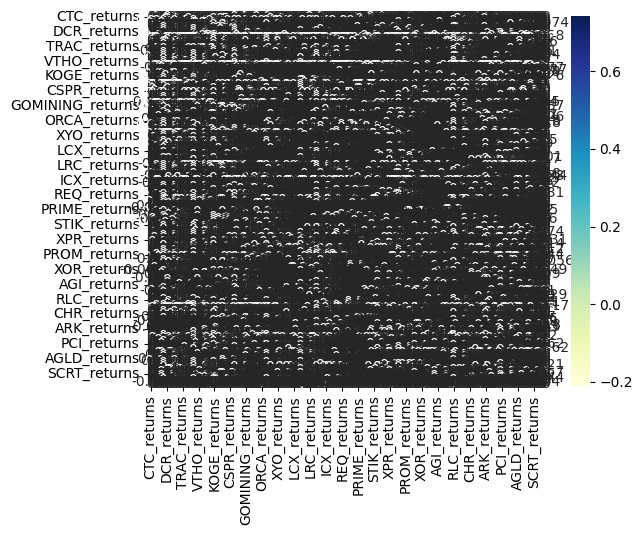

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(sparse_corr, cmap="YlGnBu", annot=True)

plt.show()

In [62]:
"""
excess_log_returns.to_csv('data/excess_log_returns.csv')
excess_log_returns.shape
"""

"\nexcess_log_returns.to_csv('excess_log_returns.csv')\nexcess_log_returns.shape\n"

In [63]:
"""
corr_long = (
    sparse_corr
    .stack()
    .reset_index(name="Correlation")
    .rename(columns={"level_0":"Asset1","level_1":"Asset2"})
)

corr_long.to_csv("data/corr_full_cleaned.csv", index=False)
"""

'\ncorr_long = (\n    sparse_corr\n    .stack()\n    .reset_index(name="Correlation")\n    .rename(columns={"level_0":"Asset1","level_1":"Asset2"})\n)\n\ncorr_long.to_csv("corr_full_cleaned.csv", index=False)\n'

Eigengap method suggests k = 2 (gap = 0.1930)


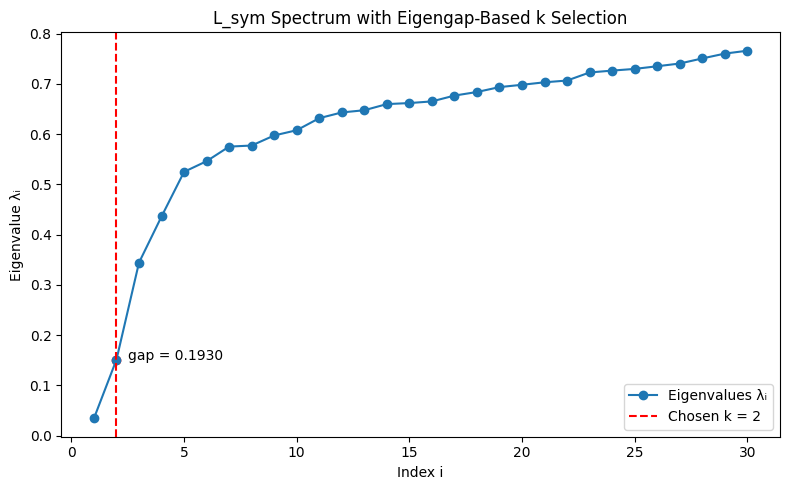

Silhouette method suggests k = 2


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

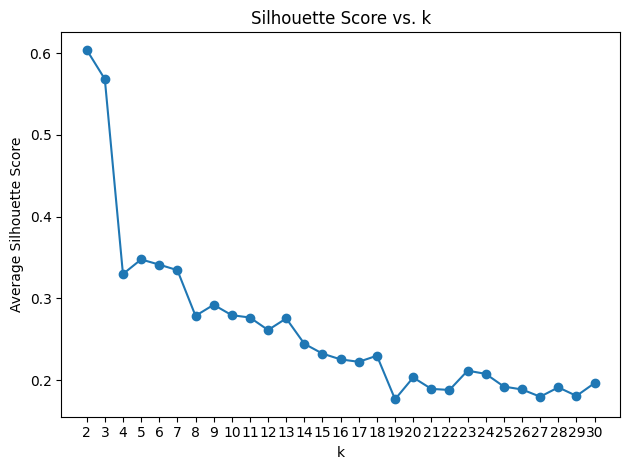

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

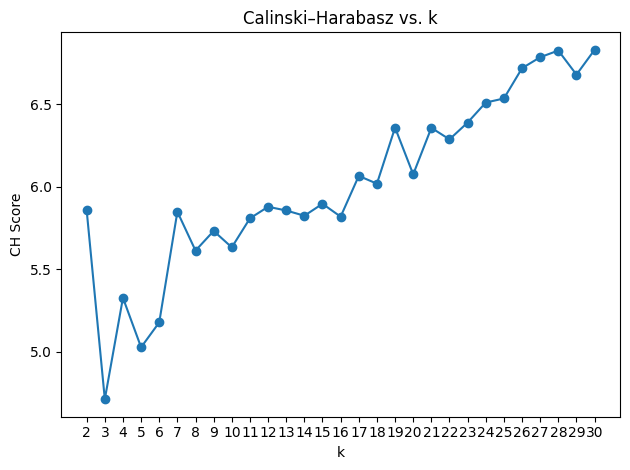

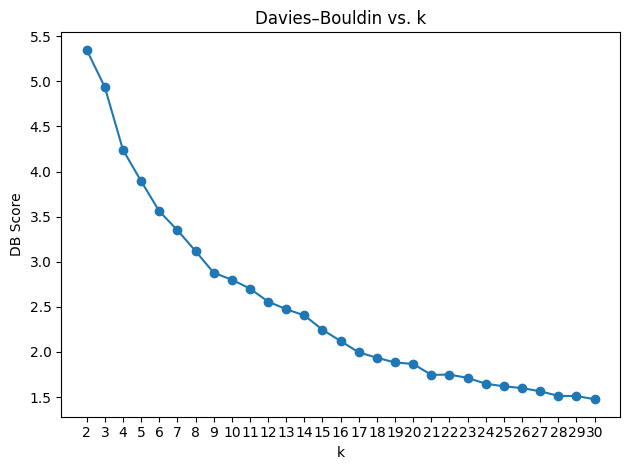

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

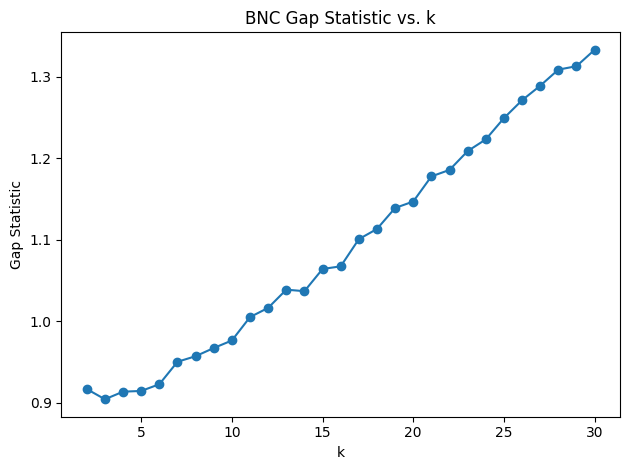

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# ------------------------------------------------------------------------------
# STEP 1: Build the signed normalized Laplacian L_sym
#
# Interpret each entry of the correlation matrix as a signed edge weight.
# Compute the diagonal degree matrix from absolute correlations, then form
#   L_sym = I - D^{-1/2} @ A @ D^{-1/2}
# so that high-degree nodes are scaled down and low-degree nodes scaled up.
# ------------------------------------------------------------------------------
A = sparse_corr.copy()
degree_vector = np.sum(np.abs(A), axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degree_vector))
I = np.eye(A.shape[0])
L_sym = I - D_inv_sqrt @ A @ D_inv_sqrt

# ------------------------------------------------------------------------------
# STEP 2: Eigen-decompose the Laplacian
#
# Compute all eigenvalues and eigenvectors of L_sym, sorted in ascending order.
# The spectrum encapsulates how easily the graph can be partitioned.
# ------------------------------------------------------------------------------
eigvals, eigvecs = eigh(L_sym)

# ------------------------------------------------------------------------------
# STEP 3: Eigengap heuristic with annotated spectrum plot
#
# Inspect the first 'eigval_limit' eigenvalues, compute successive gaps,
# ignore the trivial gap between λ1 and λ2, and choose k at the largest non-trivial jump.
# Then plot λ_i versus i, mark the chosen k and annotate the gap size.
# ------------------------------------------------------------------------------
eigval_limit = 30
vals_to_inspect = eigvals[:eigval_limit]
gaps = vals_to_inspect[1:] - vals_to_inspect[:-1]
nontrivial_idx = gaps[1:].argmax() + 1    # position in 'gaps' array
chosen_k = nontrivial_idx + 1            # cluster count = index + 1
chosen_gap = gaps[nontrivial_idx]

print(f"Eigengap method suggests k = {chosen_k} (gap = {chosen_gap:.4f})")

plt.figure(figsize=(8, 5))
plt.plot(range(1, eigval_limit+1), vals_to_inspect, marker='o', label='Eigenvalues λᵢ')
plt.axvline(chosen_k, linestyle='--', color='red', linewidth=1.5, label=f'Chosen k = {chosen_k}')
plt.scatter(chosen_k, vals_to_inspect[chosen_k-1], color='red')
plt.annotate(f'gap = {chosen_gap:.4f}', xy=(chosen_k+0.5, vals_to_inspect[chosen_k-1]))
plt.xlabel('Index i')
plt.ylabel('Eigenvalue λᵢ')
plt.title('L_sym Spectrum with Eigengap-Based k Selection')
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 4: Silhouette analysis on row-normalized spectral embedding
#
# For each k in the desired range, embed nodes into the first k eigenvectors,
# normalize each row to unit length, run KMeans, and compute the silhouette score.
# ------------------------------------------------------------------------------
max_k = 30
silhouette_scores = []
for k in range(2, max_k+1):
    U = eigvecs[:, :k]
    U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)
    silhouette_scores.append(silhouette_score(U_norm, labels))

best_sil_k = np.arange(2, max_k+1)[np.argmax(silhouette_scores)]
print(f"Silhouette method suggests k = {best_sil_k}")

plt.figure()
plt.plot(range(2, max_k+1), silhouette_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Score vs. k')
plt.xticks(range(2, max_k+1))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 5: Calinski–Harabasz and Davies–Bouldin analysis
#
# Using a fixed embedding dimension d_max, row-normalize, then for each k run
# KMeans and compute CH and DB indices. Display a table and plot both curves.
# ------------------------------------------------------------------------------
d_max = 30
U_fixed = eigvecs[:, :d_max]
U_fixed_norm = U_fixed / np.linalg.norm(U_fixed, axis=1, keepdims=True)

k_values = list(range(2, max_k+1))
ch_scores = []
db_scores = []
for k in k_values:
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_fixed_norm)
    ch_scores.append(calinski_harabasz_score(U_fixed_norm, labels))
    db_scores.append(davies_bouldin_score(U_fixed_norm, labels))

plt.figure()
plt.plot(k_values, ch_scores, marker='o', label='Calinski-Harabasz')
plt.xlabel('k')
plt.ylabel('CH Score')
plt.title('Calinski–Harabasz vs. k')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(k_values, db_scores, marker='o', label='Davies-Bouldin')
plt.xlabel('k')
plt.ylabel('DB Score')
plt.title('Davies–Bouldin vs. k')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 6: Gap statistic to guard against overfitting
#
# Compare the inertia of the real data to that of uniform reference datasets
# over multiple repeats. Plot the gap (log mean reference inertia - log real inertia)
# with error bars and identify the k with the largest meaningful gap.
# ------------------------------------------------------------------------------
def compute_gap_statistic(data, k_max, n_refs=20):
    data_min = data.min(axis=0)
    data_max = data.max(axis=0)
    gaps = np.zeros(k_max-1)
    s_k = np.zeros(k_max-1)
    for idx, k in enumerate(range(2, k_max+1)):
        km_real = KMeans(n_clusters=k, random_state=0).fit(data)
        wk_real = km_real.inertia_
        wk_refs = np.zeros(n_refs)
        for j in range(n_refs):
            random_data = np.random.rand(*data.shape) * (data_max - data_min) + data_min
            wk_refs[j] = KMeans(n_clusters=k, random_state=0).fit(random_data).inertia_
        log_refs = np.log(wk_refs)
        gaps[idx] = log_refs.mean() - np.log(wk_real)
        s_k[idx] = np.sqrt(1 + 1.0/n_refs) * log_refs.std(ddof=1)
    return gaps, s_k

gaps_vals, s_k = compute_gap_statistic(U_fixed_norm, k_max=max_k, n_refs=20)
plt.figure()
plt.plot(k_values, gaps_vals, marker='o')
plt.xlabel('k')
plt.ylabel('Gap Statistic')
plt.title('BNC Gap Statistic vs. k')
plt.tight_layout()
plt.show()

Cluster Sizes:
 • Cluster 1: 99 assets
 • Cluster 2: 75 assets

Mean Correlation to ETH:
 • Cluster 0: 0.576
 • Cluster 1: 0.424

Mean intra-cluster correlation:
 • Cluster 0: 0.217
 • Cluster 1: 0.188



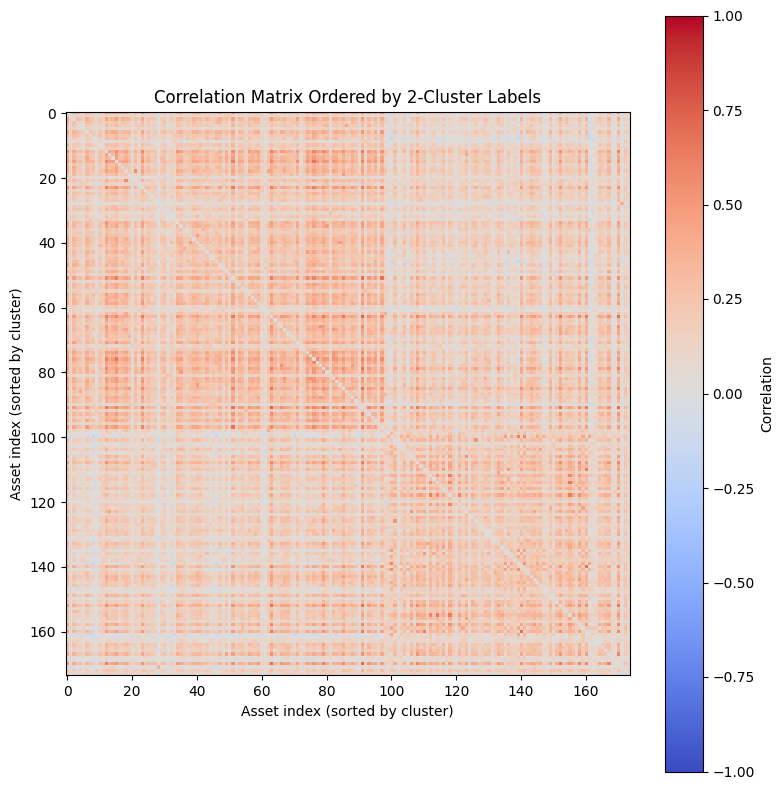

In [65]:
k = 2
eth_logrets = eth_log_returns_shared.iloc[:, 0].to_numpy()  
asset_logrets = log_returns_shared.to_numpy()  
U = eigvecs[:, :k]                      
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)  
labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# ---------------------------
# METHOD 1: Cluster sizes
# ---------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cluster_id, count in zip(unique, counts):
    print(f" • Cluster {cluster_id+1}: {count} assets")
print()

# ---------------------------
# METHOD 2: Mean correlation to ETH
# ---------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])

print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid}: {corr_to_eth[members].mean():.3f}")
print()

# ---------------------------
# METHOD 3: Intra-cluster cohesiveness
# ---------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]       
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        triu_i, triu_j = np.triu_indices(M.shape[0], k=1)
        mean_within = M[triu_i, triu_j].mean()
        print(f" • Cluster {cid}: {mean_within:.3f}")
    else:
        print(f" • Cluster {cid}: n/a (singleton)")
print()

# ---------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# ---------------------------

order = np.argsort(labels)        
corr_reordered = corr.iloc[order, order]
plt.figure(figsize=(8, 8))
plt.imshow(
    corr_reordered,
    vmin=-1, vmax=1,
    cmap='coolwarm',
    aspect='equal'
)
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

Cluster Sizes:
 • Cluster 1: 93 assets
 • Cluster 2: 51 assets
 • Cluster 3: 30 assets

Mean Correlation to ETH:
 • Cluster 0: 0.575
 • Cluster 1: 0.503
 • Cluster 2: 0.325

Mean intra-cluster correlation:
 • Cluster 0: 0.210
 • Cluster 1: 0.275
 • Cluster 2: 0.158



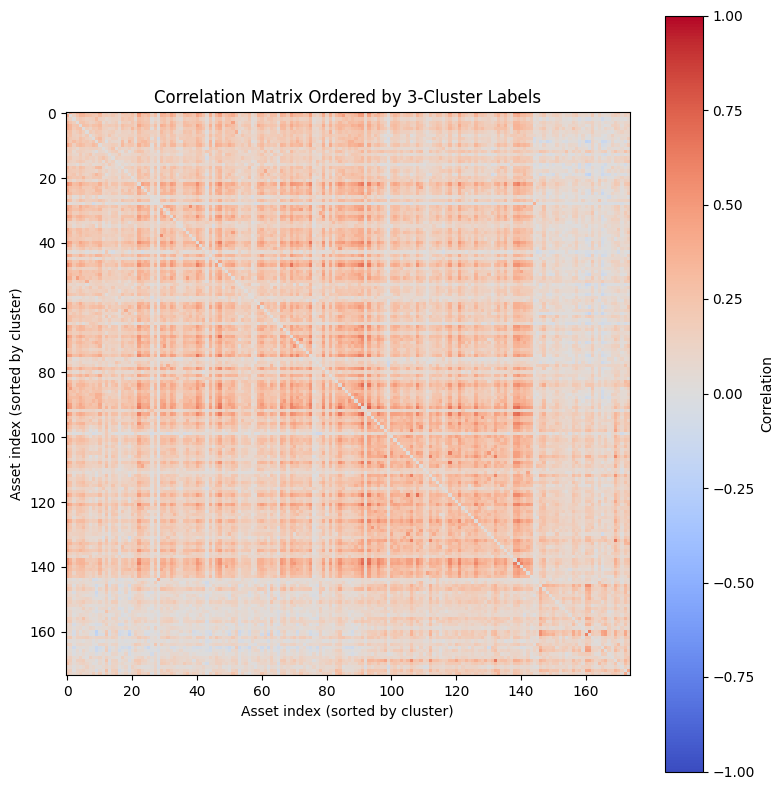

In [66]:
k = 3
eth_logrets = eth_log_returns_shared.iloc[:, 0].to_numpy()  
asset_logrets = log_returns_shared.to_numpy()  
U = eigvecs[:, :k]                      
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)  
labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# ---------------------------
# METHOD 1: Cluster sizes
# ---------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cluster_id, count in zip(unique, counts):
    print(f" • Cluster {cluster_id+1}: {count} assets")
print()

# ---------------------------
# METHOD 2: Mean correlation to ETH
# ---------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])

print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid}: {corr_to_eth[members].mean():.3f}")
print()

# ---------------------------
# METHOD 3: Intra-cluster cohesiveness
# ---------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]       
    subcorr = corr.iloc[members, members]   
    M = subcorr.values
    if M.shape[0] > 1:
        triu_i, triu_j = np.triu_indices(M.shape[0], k=1)
        mean_within = M[triu_i, triu_j].mean()
        print(f" • Cluster {cid}: {mean_within:.3f}")
    else:
        print(f" • Cluster {cid}: n/a (singleton)")
print()

# ---------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# ---------------------------

order = np.argsort(labels)        
corr_reordered = corr.iloc[order, order]
plt.figure(figsize=(8, 8))
plt.imshow(
    corr_reordered,
    vmin=-1, vmax=1,
    cmap='coolwarm',
    aspect='equal'
)
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

Cluster Sizes:
 • Cluster 1: 39 assets
 • Cluster 2: 58 assets
 • Cluster 3: 29 assets
 • Cluster 4: 48 assets

Mean Correlation to ETH:
 • Cluster 0: 0.598
 • Cluster 1: 0.452
 • Cluster 2: 0.427
 • Cluster 3: 0.561

Mean intra-cluster correlation:
 • Cluster 0: 0.208
 • Cluster 1: 0.181
 • Cluster 2: 0.245
 • Cluster 3: 0.228



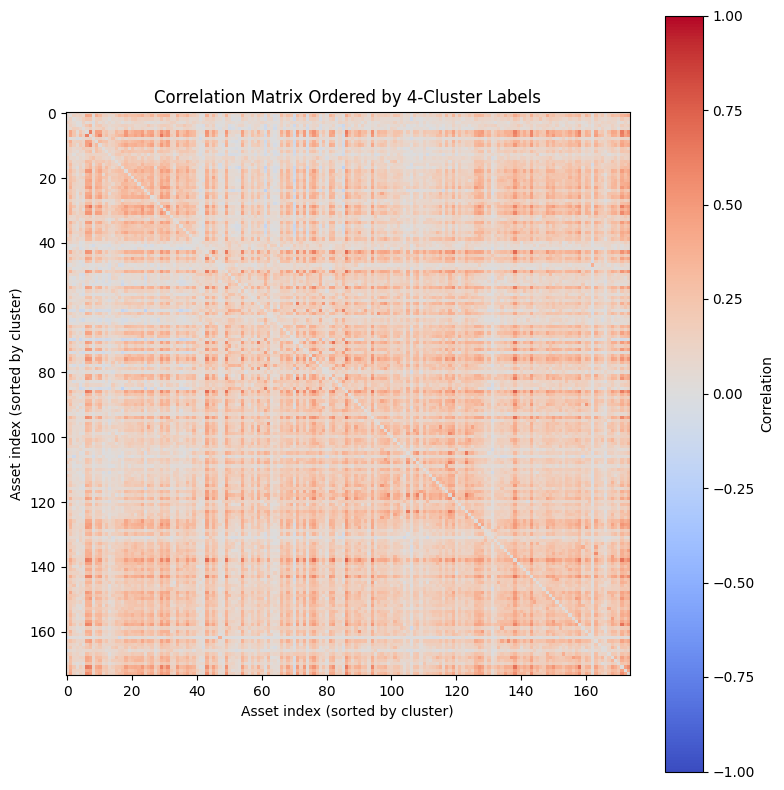

In [67]:
k = 4
eth_logrets = eth_log_returns_shared.iloc[:, 0].to_numpy()  
asset_logrets = log_returns_shared.to_numpy()  
U = eigvecs[:, :k]                      
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)  
labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# ---------------------------
# METHOD 1: Cluster sizes
# ---------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cluster_id, count in zip(unique, counts):
    print(f" • Cluster {cluster_id+1}: {count} assets")
print()

# ---------------------------
# METHOD 2: Mean correlation to ETH
# ---------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])

print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid}: {corr_to_eth[members].mean():.3f}")
print()

# ---------------------------
# METHOD 3: Intra-cluster cohesiveness
# ---------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]       
    subcorr = corr.iloc[members, members]   
    M = subcorr.values
    if M.shape[0] > 1:
        triu_i, triu_j = np.triu_indices(M.shape[0], k=1)
        mean_within = M[triu_i, triu_j].mean()
        print(f" • Cluster {cid}: {mean_within:.3f}")
    else:
        print(f" • Cluster {cid}: n/a (singleton)")
print()

# ---------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# ---------------------------

order = np.argsort(labels)        
corr_reordered = corr.iloc[order, order]
plt.figure(figsize=(8, 8))
plt.imshow(
    corr_reordered,
    vmin=-1, vmax=1,
    cmap='coolwarm',
    aspect='equal'
)
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

BNC Eigengap suggests k = 2 (gap = 0.0175)


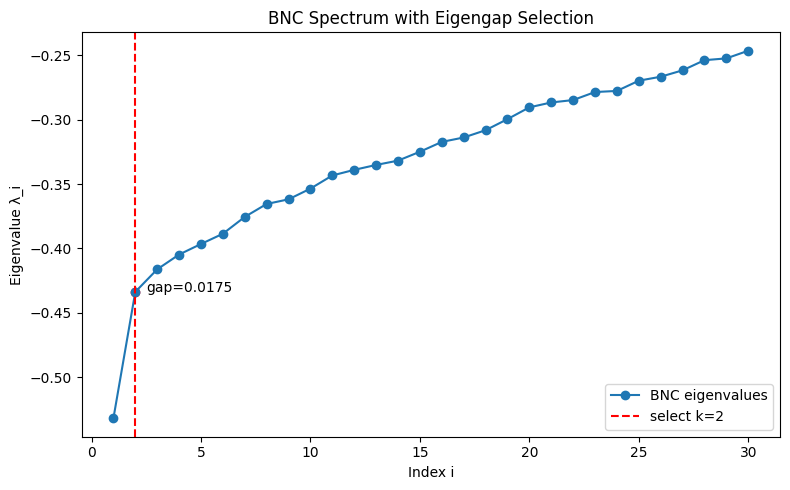

BNC Silhouette suggests k = 2


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

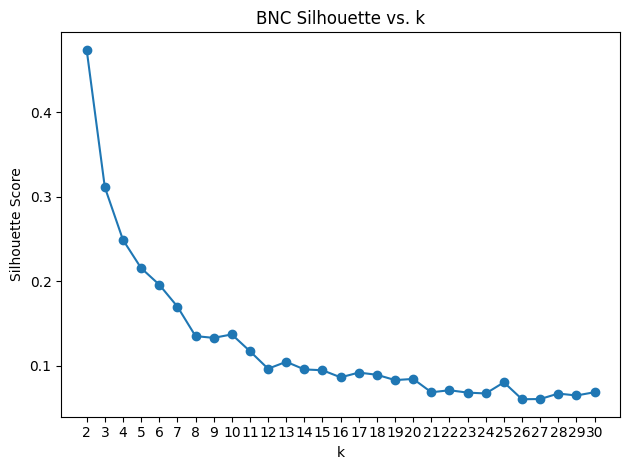

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

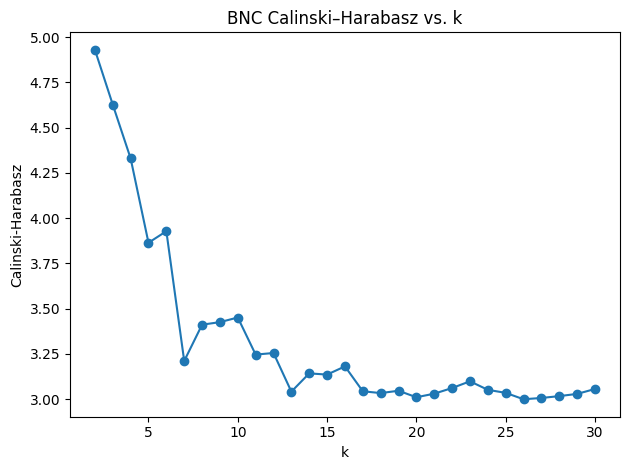

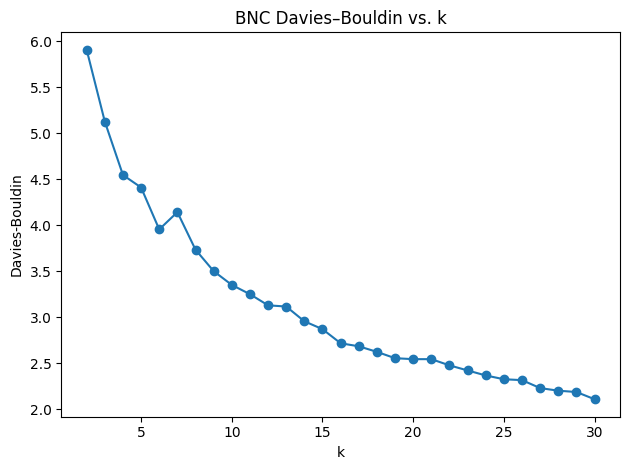

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

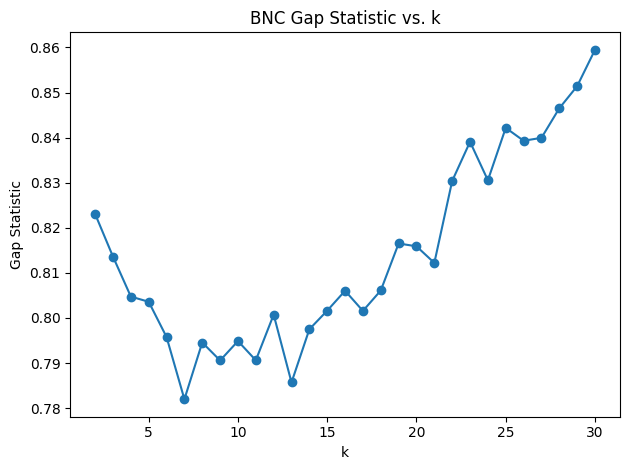

In [68]:
# -----------------------------------------------------------------------------
# BNC K-SELECTION SCRIPT
#
# This script implements multiple methods to choose the number of clusters (k)
# using Balance-Normalized Cut (BNC) spectral embedding on a signed correlation graph.
# -----------------------------------------------------------------------------

# Convert DataFrame to NumPy array
corr_array = sparse_corr.values  # shape (N, N)
N = corr_array.shape[0]

# ----------------------------------------------------------------------------
# STEP 1: Build BNC generalized eigenproblem matrices
#
# Split adjacency into positive and negative parts:
#   A_plus  = max(0, corr_array)
#   A_minus = max(0, -corr_array)
# Build degree matrices D_plus, D_minus, and total degree D_tot = D_plus + D_minus
# ----------------------------------------------------------------------------
A_plus  = np.clip(corr_array,     a_min=0, a_max=None)
A_minus = np.clip(-corr_array,    a_min=0, a_max=None)
D_plus  = np.diag(A_plus.sum(axis=1))
D_minus = np.diag(A_minus.sum(axis=1))
D_tot   = D_plus + D_minus

# ----------------------------------------------------------------------------
# STEP 2: Solve the generalized eigenproblem for BNC
#
# Solve (A_plus - A_minus) v = lambda * D_tot v
# This gives eigenvalues and eigenvectors capturing BNC structure.
# ----------------------------------------------------------------------------
L_bnc = A_plus - A_minus
eigvals_bnc, eigvecs_bnc = eigh(L_bnc, D_tot)

# ----------------------------------------------------------------------------
# STEP 3: Eigengap heuristic on BNC spectrum
#
# Inspect the first `eigval_limit` eigenvalues, compute successive gaps,
# ignore the first trivial gap, and select k at the largest non-trivial jump.
# ----------------------------------------------------------------------------
eigval_limit = 30
vals = np.sort(eigvals_bnc)[:eigval_limit]
gaps = vals[1:] - vals[:-1]
# skip gap[0], find best gap among the rest
gap_idx = np.argmax(gaps[1:]) + 1
k_eigengap = gap_idx + 1
print(f"BNC Eigengap suggests k = {k_eigengap} (gap = {gaps[gap_idx]:.4f})")

plt.figure(figsize=(8,5))
plt.plot(range(1, eigval_limit+1), vals, marker='o', label='BNC eigenvalues')
plt.axvline(k_eigengap, linestyle='--', color='red', label=f'select k={k_eigengap}')
plt.scatter(k_eigengap, vals[k_eigengap-1], color='red')
plt.annotate(f"gap={gaps[gap_idx]:.4f}", xy=(k_eigengap+0.5, vals[k_eigengap-1]))
plt.xlabel('Index i')
plt.ylabel('Eigenvalue λ_i')
plt.title('BNC Spectrum with Eigengap Selection')
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# STEP 4: Silhouette analysis on BNC embedding
#
# For each k in [2..max_k], embed using first k nontrivial BNC eigenvectors,
# row-normalize, run KMeans, and compute silhouette score.
# ----------------------------------------------------------------------------
max_k = 30
silhouette_scores = []
for k in range(2, max_k+1):
    U = eigvecs_bnc[:, :k]                  
    U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)
    silhouette_scores.append(silhouette_score(U_norm, labels))

k_sil = np.arange(2, max_k+1)[np.argmax(silhouette_scores)]
print(f"BNC Silhouette suggests k = {k_sil}")

plt.figure()
plt.plot(range(2, max_k+1), silhouette_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('BNC Silhouette vs. k')
plt.xticks(range(2, max_k+1))
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# STEP 5: Calinski–Harabasz & Davies–Bouldin on fixed BNC embedding
#
# Use d_max nontrivial BNC vectors, row-normalize, then sweep k.
# ----------------------------------------------------------------------------
d_max = 30
U_fixed = eigvecs_bnc[:, 1:d_max+1]
U_fixed_norm = U_fixed / np.linalg.norm(U_fixed, axis=1, keepdims=True)

k_vals = list(range(2, max_k+1))
ch_scores = []
db_scores = []
for k in k_vals:
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_fixed_norm)
    ch_scores.append(calinski_harabasz_score(U_fixed_norm, labels))
    db_scores.append(davies_bouldin_score(U_fixed_norm, labels))

plt.figure()
plt.plot(k_vals, ch_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Calinski-Harabasz')
plt.title('BNC Calinski–Harabasz vs. k')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(k_vals, db_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Davies-Bouldin')
plt.title('BNC Davies–Bouldin vs. k')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# STEP 6: Gap statistic on BNC embedding
#
# Compare inertia of BNC embedding to uniform random references.
# ----------------------------------------------------------------------------
def compute_gap_statistic(data, k_max, n_refs=20):
    data_min = data.min(axis=0)
    data_max = data.max(axis=0)
    gaps = np.zeros(k_max-1)
    for idx, k in enumerate(range(2, k_max+1)):
        km_real = KMeans(n_clusters=k, random_state=0).fit(data)
        w_real = km_real.inertia_
        w_refs = []
        for _ in range(n_refs):
            rnd = np.random.rand(*data.shape)*(data_max-data_min)+data_min
            w_refs.append(KMeans(n_clusters=k, random_state=0).fit(rnd).inertia_)
        gaps[idx] = np.log(np.mean(w_refs)) - np.log(w_real)
    return gaps

gaps_vals = compute_gap_statistic(U_fixed_norm, k_max=max_k, n_refs=20)
plt.figure()
plt.plot(k_vals, gaps_vals, marker='o')
plt.xlabel('k')
plt.ylabel('Gap Statistic')
plt.title('BNC Gap Statistic vs. k')
plt.tight_layout()
plt.show()


Cluster Sizes:
 • Cluster 1: 85 assets
 • Cluster 2: 89 assets

Mean Correlation to ETH:
 • Cluster 1: 0.499
 • Cluster 2: 0.522

Mean intra-cluster correlation:
 • Cluster 1: 0.174
 • Cluster 2: 0.173



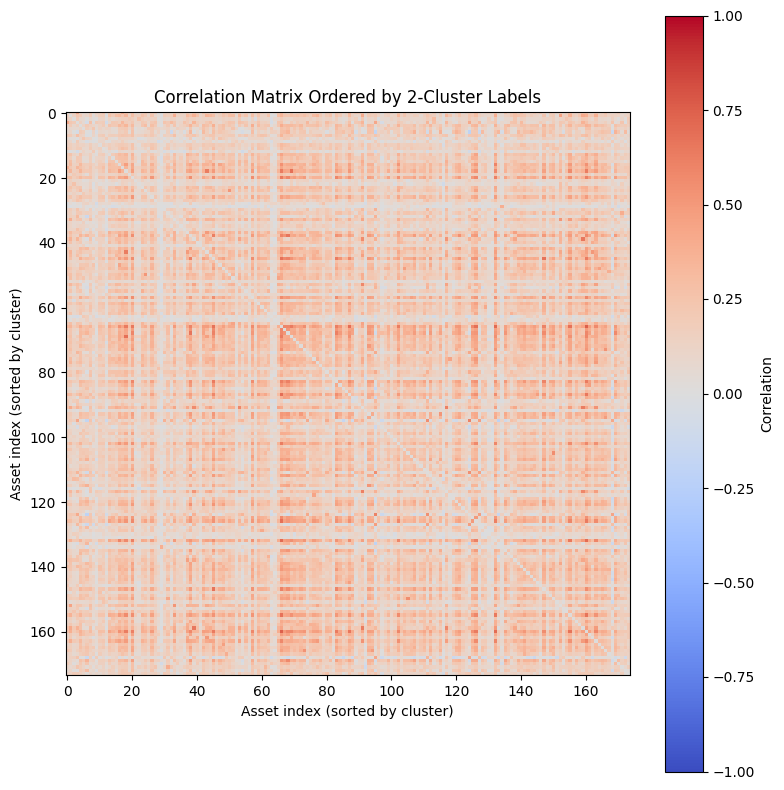

In [69]:
k = 2
eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy()  
asset_logrets = log_returns_shared.to_numpy()              

# --------------------------------------------------------------------------
# STEP A: BNC Embedding
#   Split corr into positive/negative, build D_tot, solve generalized eigenproblem
# --------------------------------------------------------------------------
A_plus  = sparse_corr.clip(lower=0)          
A_minus = (-sparse_corr).clip(lower=0)    

D_plus  = np.diag(A_plus.sum(axis=1).values)
D_minus = np.diag(A_minus.sum(axis=1).values)
D_tot   = D_plus + D_minus

L_bnc = A_plus.values - A_minus.values
eigvals_bnc, eigvecs_bnc = eigh(L_bnc, D_tot)

U      = eigvecs_bnc[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0,1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i,j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i,j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8,8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

Cluster Sizes:
 • Cluster 1: 55 assets
 • Cluster 2: 62 assets
 • Cluster 3: 57 assets

Mean Correlation to ETH:
 • Cluster 1: 0.537
 • Cluster 2: 0.516
 • Cluster 3: 0.480

Mean intra-cluster correlation:
 • Cluster 1: 0.198
 • Cluster 2: 0.153
 • Cluster 3: 0.185



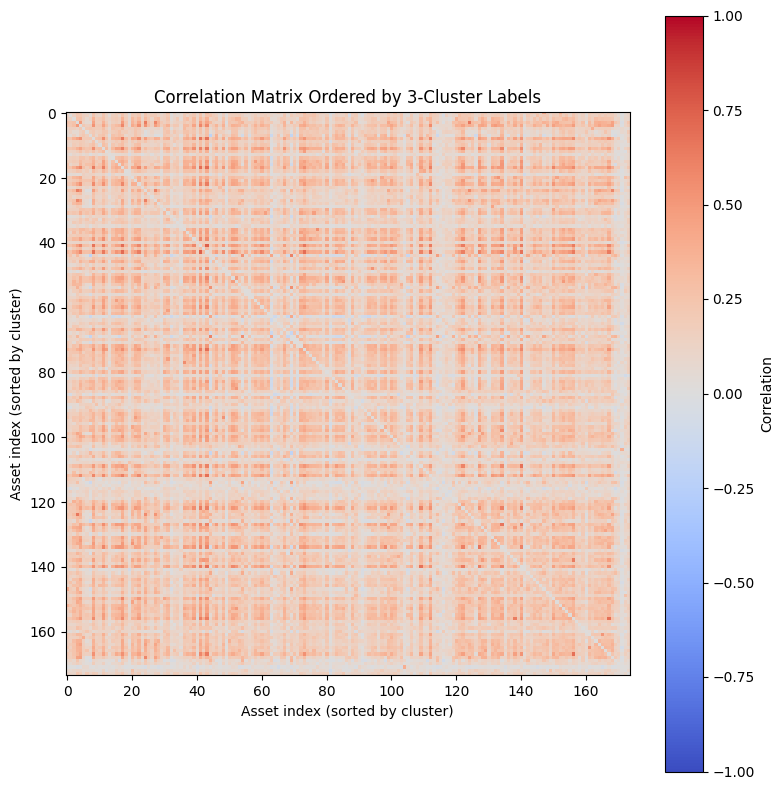

In [70]:
k = 3
eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy()  
asset_logrets = log_returns_shared.to_numpy()              

# --------------------------------------------------------------------------
# STEP A: BNC Embedding
#   Split corr into positive/negative, build D_tot, solve generalized eigenproblem
# --------------------------------------------------------------------------
A_plus  = sparse_corr.clip(lower=0)          
A_minus = (-sparse_corr).clip(lower=0)    

D_plus  = np.diag(A_plus.sum(axis=1).values)
D_minus = np.diag(A_minus.sum(axis=1).values)
D_tot   = D_plus + D_minus

L_bnc = A_plus.values - A_minus.values
eigvals_bnc, eigvecs_bnc = eigh(L_bnc, D_tot)

U      = eigvecs_bnc[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0,1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i,j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i,j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8,8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

Cluster Sizes:
 • Cluster 1: 43 assets
 • Cluster 2: 48 assets
 • Cluster 3: 39 assets
 • Cluster 4: 44 assets

Mean Correlation to ETH:
 • Cluster 1: 0.556
 • Cluster 2: 0.531
 • Cluster 3: 0.504
 • Cluster 4: 0.451

Mean intra-cluster correlation:
 • Cluster 1: 0.192
 • Cluster 2: 0.180
 • Cluster 3: 0.220
 • Cluster 4: 0.143



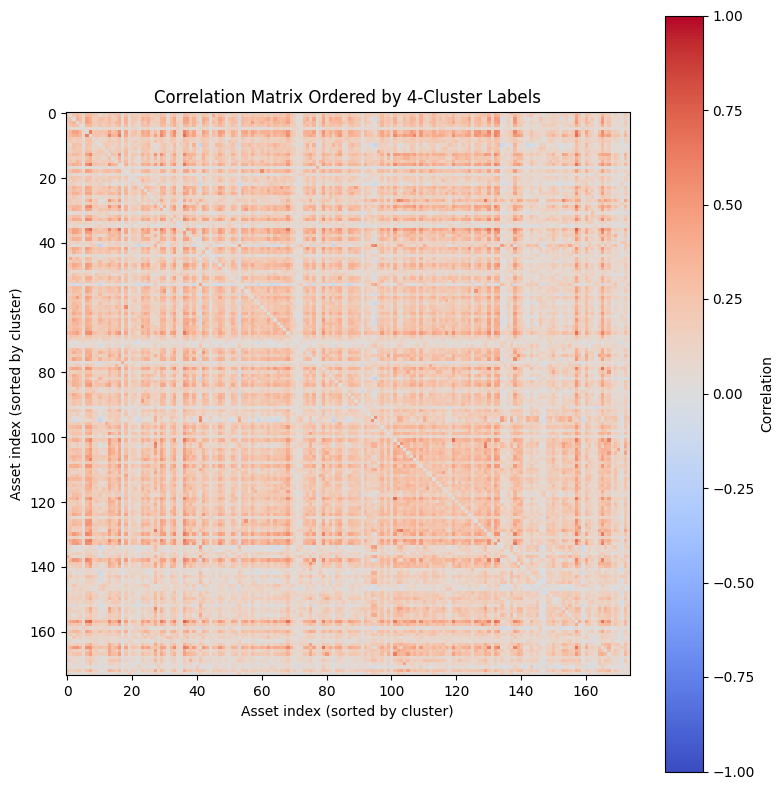

In [71]:
k = 4
eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy()  
asset_logrets = log_returns_shared.to_numpy()              

# --------------------------------------------------------------------------
# STEP A: BNC Embedding
#   Split corr into positive/negative, build D_tot, solve generalized eigenproblem
# --------------------------------------------------------------------------
A_plus  = sparse_corr.clip(lower=0)          
A_minus = (-sparse_corr).clip(lower=0)    

D_plus  = np.diag(A_plus.sum(axis=1).values)
D_minus = np.diag(A_minus.sum(axis=1).values)
D_tot   = D_plus + D_minus

L_bnc = A_plus.values - A_minus.values
eigvals_bnc, eigvecs_bnc = eigh(L_bnc, D_tot)

U      = eigvecs_bnc[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0,1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i,j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i,j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8,8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

SPONGE Eigengap suggests k = 2 (gap = 0.1344)


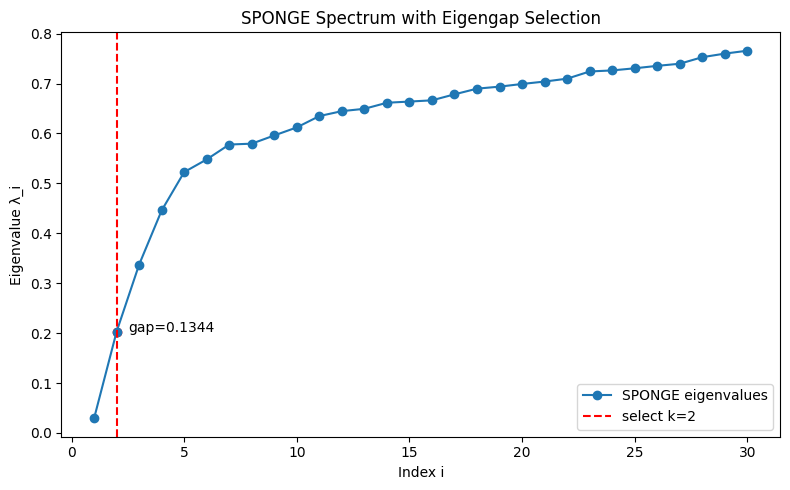

SPONGE Silhouette suggests k = 2


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

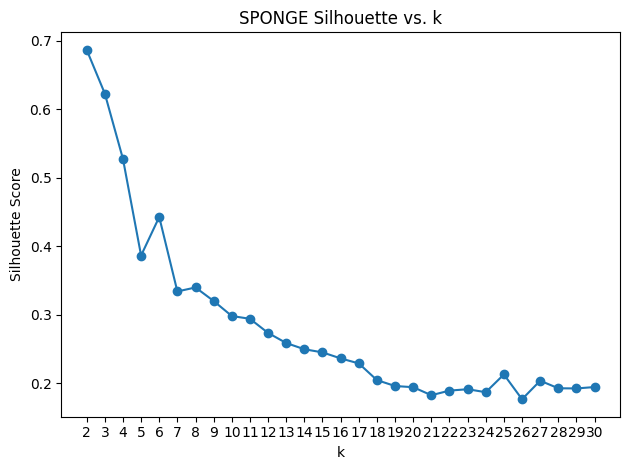

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

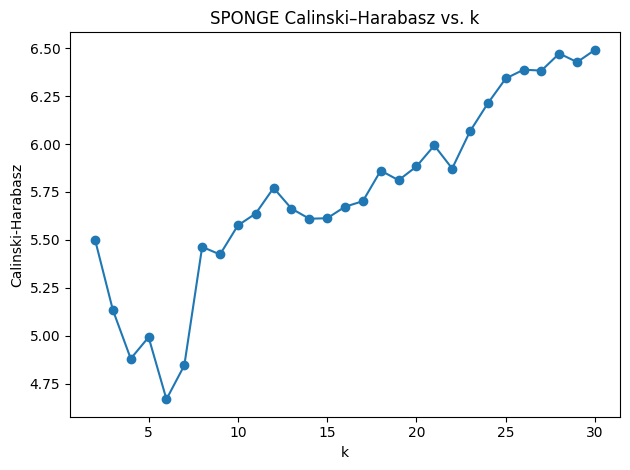

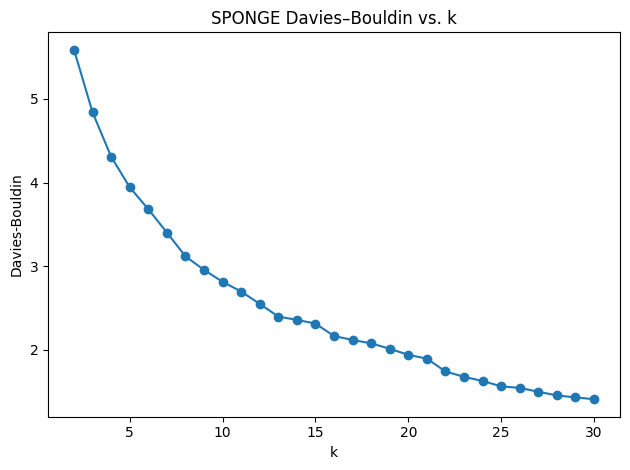

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

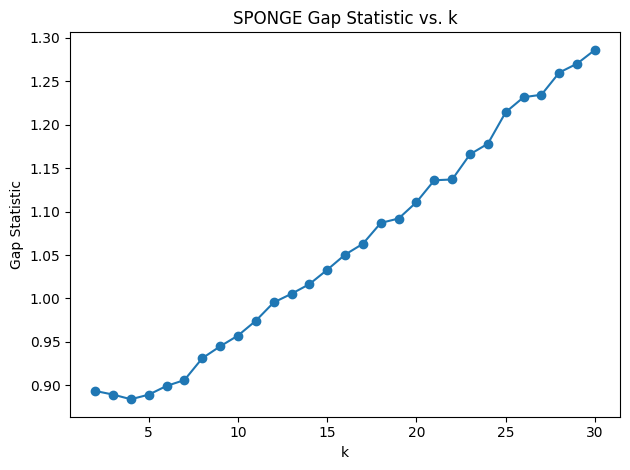

In [72]:
# -----------------------------------------------------------------------------
# SPONGE K-SELECTION SCRIPT
#
# This script implements multiple methods to choose the number of clusters (k)
# using the SPONGE (Signed Positive Over Negative Generalized Eigenproblem)
# spectral embedding on a signed correlation graph.
# -----------------------------------------------------------------------------

# Convert DataFrame to NumPy array
corr_array = sparse_corr.values  # shape (N, N)
N = corr_array.shape[0]

# ----------------------------------------------------------------------------
# PARAMETERS for SPONGE
# ----------------------------------------------------------------------------
# Regularization parameters (τ⁺, τ⁻) can be tuned; defaults to 1.0
tau_plus = 1.0
tau_minus = 1.0

# ----------------------------------------------------------------------------
# STEP 1: Build SPONGE generalized eigenproblem matrices
#
# Definitions from Cucuringu et al.:
#  A₊  = max(0, corr)
#  A₋  = max(0, -corr)
#  L₊  = D₊ - A₊    (positive-edge Laplacian)
#  L₋  = D₋ - A₋    (negative-edge Laplacian)
#  D₊, D₋ are the degree matrices of A₊, A₋
# The SPONGE eigenproblem is:
#   (L₊ + τ⁻ D₋) v = λ (L₋ + τ⁺ D₊) v
# ----------------------------------------------------------------------------
A_plus  = np.clip(corr_array,    a_min=0, a_max=None)
A_minus = np.clip(-corr_array,   a_min=0, a_max=None)

D_plus  = np.diag(A_plus.sum(axis=1))
D_minus = np.diag(A_minus.sum(axis=1))

L_plus  = D_plus - A_plus
L_minus = D_minus - A_minus

M1 = L_plus  + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

# Solve the generalized eigenproblem M1 v = λ M2 v
eigvals_s, eigvecs_s = eigh(M1, M2)

# Sort eigenvalues and eigenvectors in ascending λ
idx_sorted = np.argsort(eigvals_s)
eigvals_s = eigvals_s[idx_sorted]
eigvecs_s = eigvecs_s[:, idx_sorted]

# ----------------------------------------------------------------------------
# STEP 2: Eigengap heuristic on SPONGE spectrum
# ----------------------------------------------------------------------------
eigval_limit = min(30, N)
vals = eigvals_s[:eigval_limit]
gaps = vals[1:] - vals[:-1]
# ignore the trivial first gap, pick largest of the rest
gap_idx = np.argmax(gaps[1:]) + 1
k_eigengap = gap_idx + 1
print(f"SPONGE Eigengap suggests k = {k_eigengap} (gap = {gaps[gap_idx]:.4f})")

plt.figure(figsize=(8,5))
plt.plot(range(1, eigval_limit+1), vals, marker='o', label='SPONGE eigenvalues')
plt.axvline(k_eigengap, linestyle='--', color='red', label=f'select k={k_eigengap}')
plt.scatter(k_eigengap, vals[k_eigengap-1], color='red')
plt.annotate(f"gap={gaps[gap_idx]:.4f}", xy=(k_eigengap+0.5, vals[k_eigengap-1]))
plt.xlabel('Index i')
plt.ylabel('Eigenvalue λ_i')
plt.title('SPONGE Spectrum with Eigengap Selection')
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# STEP 3: Silhouette analysis on SPONGE embedding
# ----------------------------------------------------------------------------
max_k = 30
silhouette_scores = []
for k in range(2, max_k+1):
    # skip the first trivial eigenvector, embed on next k
    U = eigvecs_s[:, :k]
    U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)
    silhouette_scores.append(silhouette_score(U_norm, labels))

k_sil = np.arange(2, max_k+1)[np.argmax(silhouette_scores)]
print(f"SPONGE Silhouette suggests k = {k_sil}")

plt.figure()
plt.plot(range(2, max_k+1), silhouette_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('SPONGE Silhouette vs. k')
plt.xticks(range(2, max_k+1))
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# STEP 4: Calinski–Harabasz & Davies–Bouldin on fixed SPONGE embedding
# ----------------------------------------------------------------------------
d_max = 30
U_fixed = eigvecs_s[:, 1:d_max+1]
U_fixed_norm = U_fixed / np.linalg.norm(U_fixed, axis=1, keepdims=True)

k_vals = list(range(2, max_k+1))
ch_scores = []
db_scores = []
for k in k_vals:
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_fixed_norm)
    ch_scores.append(calinski_harabasz_score(U_fixed_norm, labels))
    db_scores.append(davies_bouldin_score(U_fixed_norm, labels))

plt.figure()
plt.plot(k_vals, ch_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Calinski-Harabasz')
plt.title('SPONGE Calinski–Harabasz vs. k')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(k_vals, db_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Davies-Bouldin')
plt.title('SPONGE Davies–Bouldin vs. k')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# STEP 5: Gap statistic on SPONGE embedding
# ----------------------------------------------------------------------------
def compute_gap_statistic(data, k_max, n_refs=20):
    data_min = data.min(axis=0)
    data_max = data.max(axis=0)
    gaps = np.zeros(k_max-1)
    for idx, k in enumerate(range(2, k_max+1)):
        w_real = KMeans(n_clusters=k, random_state=0).fit(data).inertia_
        w_refs = []
        for _ in range(n_refs):
            rnd = np.random.rand(*data.shape)*(data_max-data_min)+data_min
            w_refs.append(KMeans(n_clusters=k, random_state=0).fit(rnd).inertia_)
        gaps[idx] = np.log(np.mean(w_refs)) - np.log(w_real)
    return gaps

gaps_vals = compute_gap_statistic(U_fixed_norm, k_max=max_k, n_refs=20)
plt.figure()
plt.plot(k_vals, gaps_vals, marker='o')
plt.xlabel('k')
plt.ylabel('Gap Statistic')
plt.title('SPONGE Gap Statistic vs. k')
plt.tight_layout()
plt.show()

Cluster Sizes:
 • Cluster 1: 104 assets
 • Cluster 2: 70 assets

Mean Correlation to ETH:
 • Cluster 1: 0.573
 • Cluster 2: 0.418

Mean intra-cluster correlation:
 • Cluster 1: 0.215
 • Cluster 2: 0.187



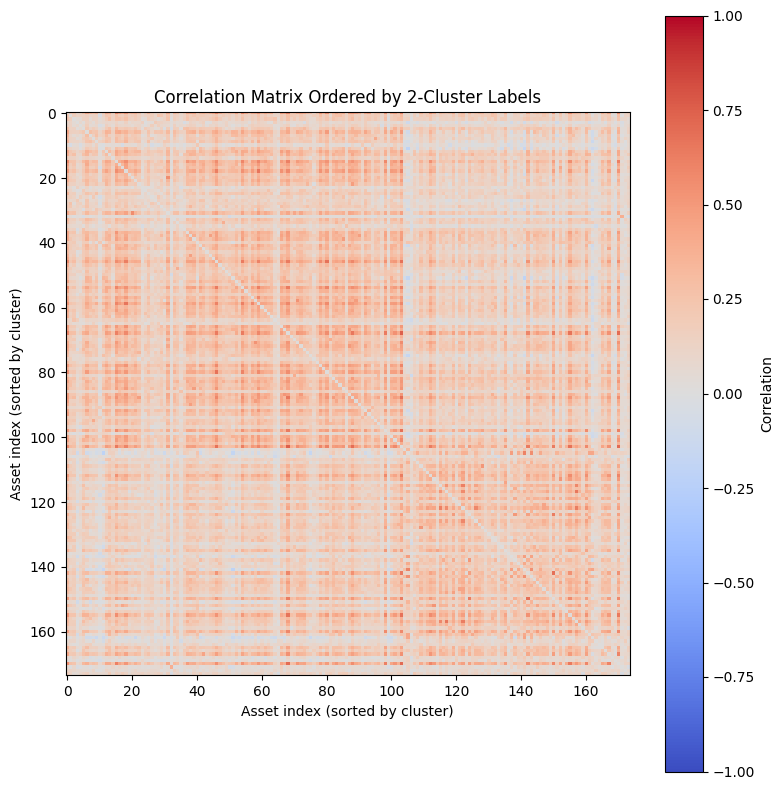

In [73]:
k = 2
tau_plus = 1.0
tau_minus = 1.0

eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy() 
asset_logrets = log_returns_shared.to_numpy()               

# --------------------------------------------------------------------------
# STEP A: SPONGE Embedding
#  Build positive/negative Laplacians and regularize as per Cucuringu et al.
# --------------------------------------------------------------------------

A_plus_df  = sparse_corr.clip(lower=0)
A_minus_df = (-sparse_corr).clip(lower=0)

D_plus   = np.diag(A_plus_df.sum(axis=1).values)
D_minus  = np.diag(A_minus_df.sum(axis=1).values)

L_plus   = D_plus - A_plus_df.values
L_minus  = D_minus - A_minus_df.values

M1 = L_plus + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

# Solve the generalized eigenproblem
eigvals_s, eigvecs_s = eigh(M1, M2)

# --------------------------------------------------------------------------
# Build the spectral embedding using the first k eigenvectors
# --------------------------------------------------------------------------
U      = eigvecs_s[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i, j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i, j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8, 8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

Cluster Sizes:
 • Cluster 1: 87 assets
 • Cluster 2: 35 assets
 • Cluster 3: 52 assets

Mean Correlation to ETH:
 • Cluster 1: 0.578
 • Cluster 2: 0.345
 • Cluster 3: 0.509

Mean intra-cluster correlation:
 • Cluster 1: 0.210
 • Cluster 2: 0.171
 • Cluster 3: 0.266



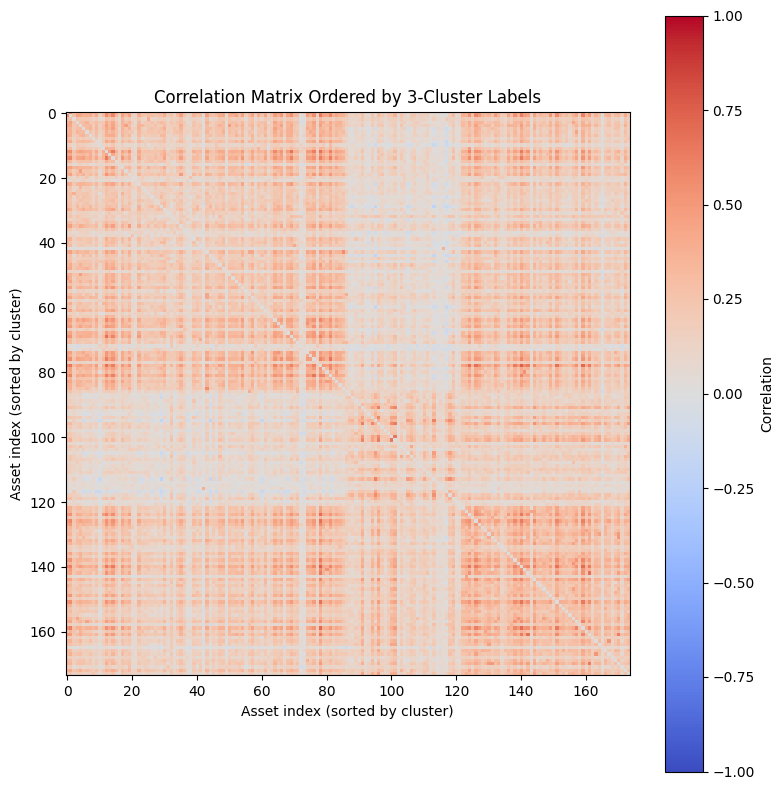

In [74]:
k = 3
tau_plus = 1.0
tau_minus = 1.0

eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy() 
asset_logrets = log_returns_shared.to_numpy()               

# --------------------------------------------------------------------------
# STEP A: SPONGE Embedding
#  Build positive/negative Laplacians and regularize as per Cucuringu et al.
# --------------------------------------------------------------------------

A_plus_df  = sparse_corr.clip(lower=0)
A_minus_df = (-sparse_corr).clip(lower=0)

D_plus   = np.diag(A_plus_df.sum(axis=1).values)
D_minus  = np.diag(A_minus_df.sum(axis=1).values)

L_plus   = D_plus - A_plus_df.values
L_minus  = D_minus - A_minus_df.values

M1 = L_plus + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

# Solve the generalized eigenproblem
eigvals_s, eigvecs_s = eigh(M1, M2)

# --------------------------------------------------------------------------
# Build the spectral embedding using the first k eigenvectors
# --------------------------------------------------------------------------
U      = eigvecs_s[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels_3_new = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique, counts = np.unique(labels_3_new, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels_3_new == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels_3_new == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i, j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i, j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels_3_new)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8, 8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

In [75]:
token_summary = pd.read_csv('data/token_summary.csv')
token_summary.set_index('symbol', inplace=True)
token_summary.head()

,circulating_supply,price_usd,market_cap_usd
symbol,,,
DGB,1.771598e+10,0.009832,1.741816e+08
DASH,1.227934e+07,23.742810,2.915461e+08
XVG,1.652195e+10,0.007502,1.239501e+08
XEM,9.000000e+09,0.009851,8.865895e+07
SC,5.602564e+10,0.003461,1.939043e+08


In [76]:
# 1. Compute ETH-to-asset correlations
if isinstance(eth_log_returns_shared, pd.DataFrame):
    eth_series = eth_log_returns_shared.iloc[:, 0]
else:
    eth_series = eth_log_returns_shared

# Align indices
common_idx = excess_log_returns.index.intersection(eth_series.index)
eth_series = eth_series.loc[common_idx]
excess = excess_log_returns.loc[common_idx]
# Drop '_returns' suffix for corr index matching
assets = [col.rsplit('_', 1)[0] for col in excess.columns]
excess.columns = assets

# Compute correlations
rho_eth = excess.corrwith(eth_series)

# 2. Variance of ρ→ETH per cluster
print("Variance of ρ→ETH per cluster:")
for cid in np.unique(labels_3_new):
    members = [assets[i] for i, lab in enumerate(labels_3_new) if lab == cid]
    var_val = rho_eth.loc[members].var()
    print(f" • Cluster {cid+1} (n={len(members)}): var = {var_val:.4f}")

# 3. Build feature summary for each cluster
rows = []
for cid in np.unique(labels_3_new):
    members = [assets[i] for i, lab in enumerate(labels_3_new) if lab == cid]
    
    # Volume columns have '_volumes' suffix
    vol_cols = [f"{asset}_volumes" for asset in members]
    vol_df = volumes[vol_cols]
    
    # Return cols: '{asset}_returns'
    ret_cols = [f"{asset}_returns" for asset in members]
    ret_df = excess_log_returns[ret_cols]
    # Align index for volatility
    ret_df = ret_df.loc[common_idx]
    
    # Token fundamentals
    ts = token_summary.loc[members]
    
    rows.append({
        'cluster':                 cid+1,
        'n_assets':                len(members),
        'var_rho_eth':             rho_eth.loc[members].var(),
        'mean_daily_volume':       vol_df.mean().mean(),
        'avg_excess_log_vol':      ret_df.std().mean(),
        'mean_price_usd':          ts['price_usd'].mean(),
        'mean_circ_supply':        ts['circulating_supply'].mean(),
        'mean_market_cap_usd':     ts['market_cap_usd'].mean(),
    })

summary_df = pd.DataFrame(rows)
summary_df.set_index('cluster', inplace=True)
summary_df

Variance of ρ→ETH per cluster:
 • Cluster 1 (n=87): var = 0.0084
 • Cluster 2 (n=35): var = 0.0334
 • Cluster 3 (n=52): var = 0.0054


,n_assets,var_rho_eth,mean_daily_volume,avg_excess_log_vol,mean_price_usd,mean_circ_supply,mean_market_cap_usd
cluster,,,,,,,
1,87,0.008450,2.270122e+07,0.051148,2.227696,4.526408e+18,1.399172e+08
2,35,0.033404,5.208686e+06,0.053628,2.591001,1.092973e+10,1.305826e+08
3,52,0.005364,2.502703e+07,0.047725,109.767631,3.941919e+09,1.422904e+08



--- Cluster 1: No-PC Removal Analysis (87 assets) ---

PC1 loadings (sorted):
           Asset  PC1_loading
3    ZIL_returns     0.171306
68  DENT_returns     0.167774
16   ONE_returns     0.166850
30   ENJ_returns     0.162015
75  CELR_returns     0.160502
..           ...          ...
86   0x0_returns     0.039370
13  CHEX_returns     0.035994
31   ZIG_returns     0.031248
73  ELON_returns     0.026677
58   XOR_returns     0.015379

[87 rows x 2 columns]


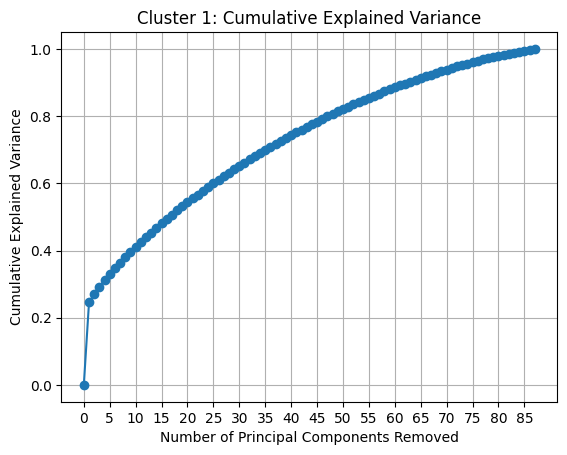

Top 10 positive z-scores (no PC removal):
GLMR_returns    2.277595
WILD_returns    0.704165
IOTX_returns    0.526862
XVG_returns     0.249501
ORDI_returns    0.199629
YGG_returns     0.196380
BAL_returns     0.139817
LQTY_returns    0.058213
XCH_returns     0.046552
BNT_returns     0.009666
Name: 2025-05-28, dtype: float64
Top 10 negative z-scores (no PC removal):
CFG_returns     -1.696211
LRC_returns     -1.297548
0x0_returns     -1.179684
HEART_returns   -1.151128
EDU_returns     -1.065782
CHR_returns     -1.055418
FIDA_returns    -0.991649
ORCA_returns    -0.965352
CHEX_returns    -0.951866
CGPT_returns    -0.951377
Name: 2025-05-28, dtype: float64

--- Cluster 3: No-PC Removal Analysis (52 assets) ---

PC1 loadings (sorted):
              Asset  PC1_loading
7       BAT_returns     0.206280
26      ICX_returns     0.204504
37     IOST_returns     0.194423
13     ANKR_returns     0.191071
51      KNC_returns     0.182834
32     WAXP_returns     0.182251
24      ONT_returns     0.1805

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


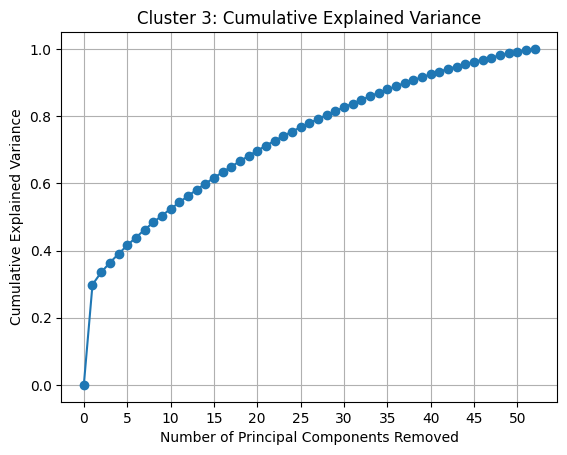

Top 10 positive z-scores (no PC removal):
MASK_returns    3.525367
LCX_returns     2.099409
SNT_returns     1.829932
ICX_returns     0.744298
HIVE_returns    0.307969
ARK_returns     0.107896
DAG_returns    -0.014711
ACT_returns    -0.086926
REQ_returns    -0.087056
XVS_returns    -0.099036
Name: 2025-05-28, dtype: float64
Top 10 negative z-scores (no PC removal):
KEEP_returns    -5.340686
XEM_returns     -4.582049
AERGO_returns   -1.427570
AWE_returns     -0.998446
ARDR_returns    -0.862899
MTL_returns     -0.855381
BAT_returns     -0.847687
XNO_returns     -0.829072
TFUEL_returns   -0.783375
QTUM_returns    -0.718399
Name: 2025-05-28, dtype: float64


In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# We keep clusters 1 and 3 (labels 0 and 2 in zero-based `labels_3_new`)
keep_cids = [0, 2]

for cid in keep_cids:
    members = [assets[i] for i, lab in enumerate(labels_3_new) if lab == cid]
    print(f"\n--- Cluster {cid+1}: No-PC Removal Analysis ({len(members)} assets) ---")
    
    # 1. Extract and align returns
    ret_cols = [f"{m}_returns" for m in members]
    ret_df = excess_log_returns.loc[common_idx, ret_cols].dropna()
    
    # 2. Standardize returns (zero mean, unit variance)
    scaler = StandardScaler()
    ret_std = pd.DataFrame(
        scaler.fit_transform(ret_df),
        index=ret_df.index,
        columns=ret_df.columns
    )
    
    # 3. Fit PCA and compute cumulative explained variance including 0 PCs
    pca = PCA()
    pca.fit(ret_std)
    pc1_loadings = pca.components_[0]   # shape = (n_assets_in_cluster,)

    loading_df = pd.DataFrame({
        "Asset": ret_std.columns,
        "PC1_loading": pc1_loadings
    }).sort_values("PC1_loading", ascending=False)
    print("\nPC1 loadings (sorted):")
    print(loading_df)

    evr = pca.explained_variance_ratio_

    # Prepend zero for 0 PCs removed
    cum_evr = np.concatenate([[0.0], np.cumsum(evr)])
    pcs = np.arange(len(cum_evr))  # [0, 1, 2, ...]

    # 4. Plot cumulative explained variance with x-axis ticks every 5 PCs removed
    plt.figure()
    plt.plot(pcs, cum_evr, marker='o')
    plt.title(f"Cluster {cid+1}: Cumulative Explained Variance")
    plt.xlabel("Number of Principal Components Removed")
    plt.ylabel("Cumulative Explained Variance")
    max_pc = pcs[-1]
    xticks = np.arange(0, max_pc + 1, 5)
    plt.xticks(xticks)
    plt.grid(True)
    plt.show()
    
    # 5. Use standardized returns directly as residuals (no PCs removed)
    residuals_df = ret_std.copy()
    
    # 6. These are already z-scores by construction (mean=0, std=1)
    res_z = residuals_df
    
    # 7. Display top anomalies on most recent date
    latest = res_z.iloc[-1]
    print("Top 10 positive z-scores (no PC removal):")
    print(latest.nlargest(10))
    print("Top 10 negative z-scores (no PC removal):")
    print(latest.nsmallest(10))

In [78]:
# Keep clusters 1 & 3 (zero-based labels 0 and 2 in `labels_3_new`)
keep_cids = [0, 2]

for cid in keep_cids:
    members = [assets[i] for i, lab in enumerate(labels_3_new) if lab == cid]
    print(f"\n--- Cluster {cid+1}: PC1-Removed Residual Analysis ({len(members)} assets) ---")

    # 1. Extract and align returns
    ret_cols = [f"{m}_returns" for m in members]
    ret_df   = excess_log_returns.loc[common_idx, ret_cols].dropna()

    # 2. Standardize
    scaler   = StandardScaler()
    ret_std  = pd.DataFrame(
        scaler.fit_transform(ret_df),
        index=ret_df.index,
        columns=ret_df.columns
    )

    # 3. Fit PCA and get scores
    pca      = PCA()
    scores   = pca.fit_transform(ret_std)

    # 4. Reconstruct only the first principal component (PC1)
    pc1_scores   = scores[:, [0]]                # shape (n_days, 1)
    pc1_loadings = pca.components_[0:1, :]       # shape (1, n_assets)
    recon_pc1_std= pc1_scores @ pc1_loadings     # in standardized space
    recon_pc1    = scaler.inverse_transform(recon_pc1_std)

    # 5. Compute residuals (removing PC1) and z-score them
    residuals     = ret_df.values - recon_pc1
    residuals_df  = pd.DataFrame(residuals, index=ret_df.index, columns=ret_df.columns)
    res_z         = (residuals_df - residuals_df.mean()) / residuals_df.std()

    # 6. Print top/bottom 10 anomalies on the most recent date
    latest = res_z.iloc[-1]
    print("Top 10 positive residual z-scores after PC1 removal:")
    print(latest.nlargest(10))
    print("Top 10 negative residual z-scores after PC1 removal:")
    print(latest.nsmallest(10))


--- Cluster 1: PC1-Removed Residual Analysis (87 assets) ---
Top 10 positive residual z-scores after PC1 removal:
GLMR_returns    3.507998
IOTX_returns    1.141099
WILD_returns    0.925075
YGG_returns     0.756692
XVG_returns     0.602429
ORDI_returns    0.568224
BAL_returns     0.564571
ILV_returns     0.534729
SNX_returns     0.509647
LUNA_returns    0.475913
Name: 2025-05-28, dtype: float64
Top 10 negative residual z-scores after PC1 removal:
CFG_returns     -1.513645
LRC_returns     -1.054947
0x0_returns     -1.052550
HEART_returns   -1.011479
CHEX_returns    -0.831243
ORCA_returns    -0.782449
ACX_returns     -0.763712
EDU_returns     -0.734882
CHR_returns     -0.721763
CGPT_returns    -0.692697
Name: 2025-05-28, dtype: float64

--- Cluster 3: PC1-Removed Residual Analysis (52 assets) ---
Top 10 positive residual z-scores after PC1 removal:
MASK_returns    4.736416
SNT_returns     2.505110
LCX_returns     2.387295
ICX_returns     2.314103
HIVE_returns    0.799889
ARK_returns     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3

Cluster Sizes:
 • Cluster 1: 26 assets
 • Cluster 2: 26 assets
 • Cluster 3: 46 assets
 • Cluster 4: 76 assets

Mean Correlation to ETH:
 • Cluster 1: 0.412
 • Cluster 2: 0.316
 • Cluster 3: 0.550
 • Cluster 4: 0.588

Mean intra-cluster correlation:
 • Cluster 1: 0.225
 • Cluster 2: 0.152
 • Cluster 3: 0.257
 • Cluster 4: 0.228



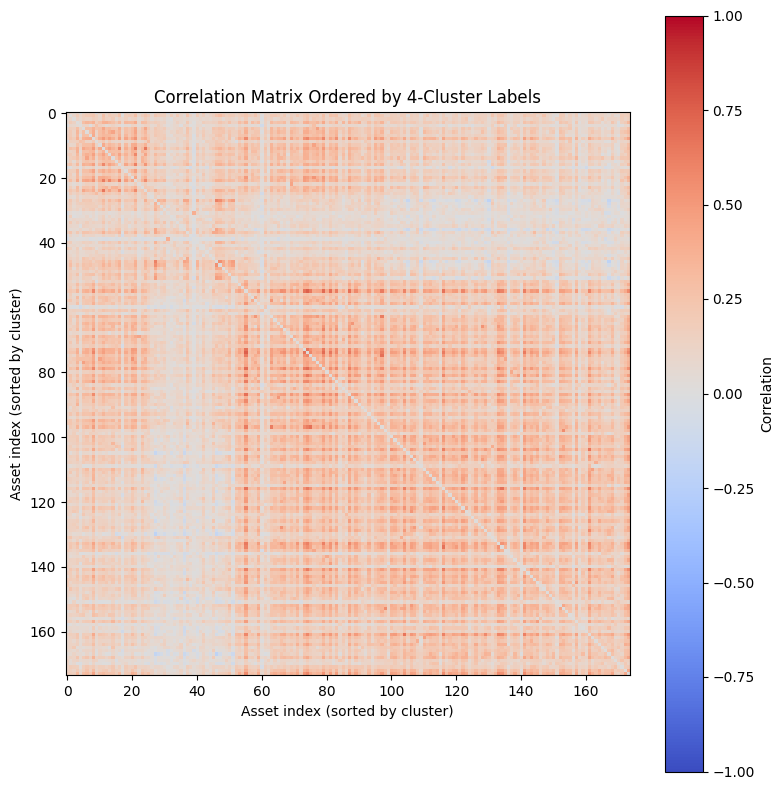

In [79]:
k = 4
tau_plus = 1.0
tau_minus = 1.0

eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy() 
asset_logrets = log_returns_shared.to_numpy()               

# --------------------------------------------------------------------------
# STEP A: SPONGE Embedding
#  Build positive/negative Laplacians and regularize as per Cucuringu et al.
# --------------------------------------------------------------------------

A_plus_df  = sparse_corr.clip(lower=0)
A_minus_df = (-sparse_corr).clip(lower=0)

D_plus   = np.diag(A_plus_df.sum(axis=1).values)
D_minus  = np.diag(A_minus_df.sum(axis=1).values)

L_plus   = D_plus - A_plus_df.values
L_minus  = D_minus - A_minus_df.values

M1 = L_plus + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

# Solve the generalized eigenproblem
eigvals_s, eigvecs_s = eigh(M1, M2)

# --------------------------------------------------------------------------
# Build the spectral embedding using the first k eigenvectors
# --------------------------------------------------------------------------
U      = eigvecs_s[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i, j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i, j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8, 8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

Cluster Sizes:
 • Cluster 1: 47 assets
 • Cluster 2: 33 assets
 • Cluster 3: 24 assets
 • Cluster 4: 34 assets
 • Cluster 5: 36 assets

Mean Correlation to ETH:
 • Cluster 1: 0.590
 • Cluster 2: 0.543
 • Cluster 3: 0.325
 • Cluster 4: 0.445
 • Cluster 5: 0.564

Mean intra-cluster correlation:
 • Cluster 1: 0.202
 • Cluster 2: 0.267
 • Cluster 3: 0.174
 • Cluster 4: 0.246
 • Cluster 5: 0.235



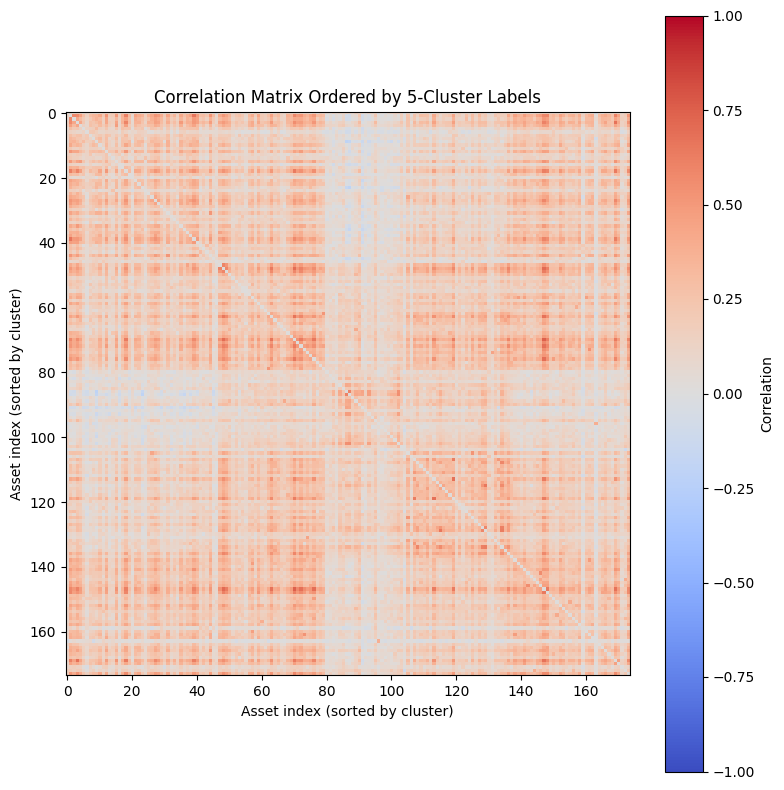

In [80]:
k = 5
tau_plus = 1.0
tau_minus = 1.0

eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy() 
asset_logrets = log_returns_shared.to_numpy()               

# --------------------------------------------------------------------------
# STEP A: SPONGE Embedding
#  Build positive/negative Laplacians and regularize as per Cucuringu et al.
# --------------------------------------------------------------------------

A_plus_df  = sparse_corr.clip(lower=0)
A_minus_df = (-sparse_corr).clip(lower=0)

D_plus   = np.diag(A_plus_df.sum(axis=1).values)
D_minus  = np.diag(A_minus_df.sum(axis=1).values)

L_plus   = D_plus - A_plus_df.values
L_minus  = D_minus - A_minus_df.values

M1 = L_plus + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

# Solve the generalized eigenproblem
eigvals_s, eigvecs_s = eigh(M1, M2)

# --------------------------------------------------------------------------
# Build the spectral embedding using the first k eigenvectors
# --------------------------------------------------------------------------
U      = eigvecs_s[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i, j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i, j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8, 8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/60412621.py:41: RuntimeWarning: divide by zero encountered in matmul
  M2_inv_sqrt = eigvecs_M2 @ inv_sqrt_vals @ eigvecs_M2.T


SPONGEsym Eigengap suggests k = 2 (gap = 0.1344)


/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/60412621.py:41: RuntimeWarning: overflow encountered in matmul
  M2_inv_sqrt = eigvecs_M2 @ inv_sqrt_vals @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/60412621.py:41: RuntimeWarning: invalid value encountered in matmul
  M2_inv_sqrt = eigvecs_M2 @ inv_sqrt_vals @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/60412621.py:43: RuntimeWarning: divide by zero encountered in matmul
  P = M2_inv_sqrt @ M1 @ M2_inv_sqrt
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/60412621.py:43: RuntimeWarning: overflow encountered in matmul
  P = M2_inv_sqrt @ M1 @ M2_inv_sqrt
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/60412621.py:43: RuntimeWarning: invalid value encountered in matmul
  P = M2_inv_sqrt @ M1 @ M2_inv_sqrt


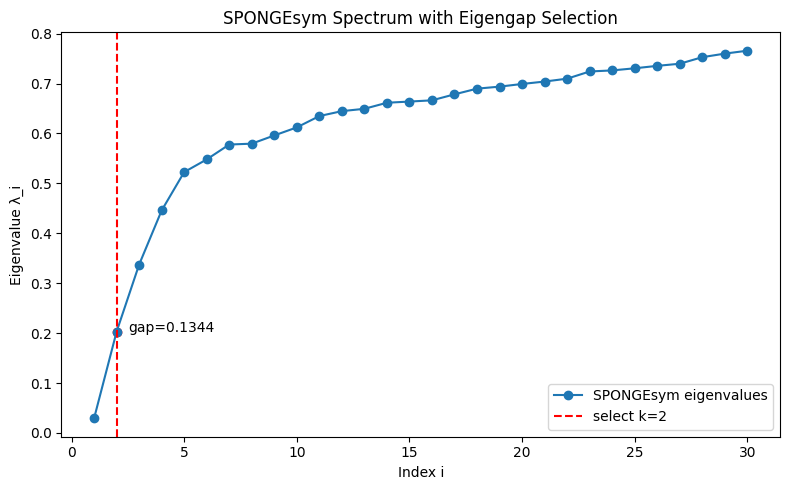

SPONGEsym Silhouette suggests k = 2


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

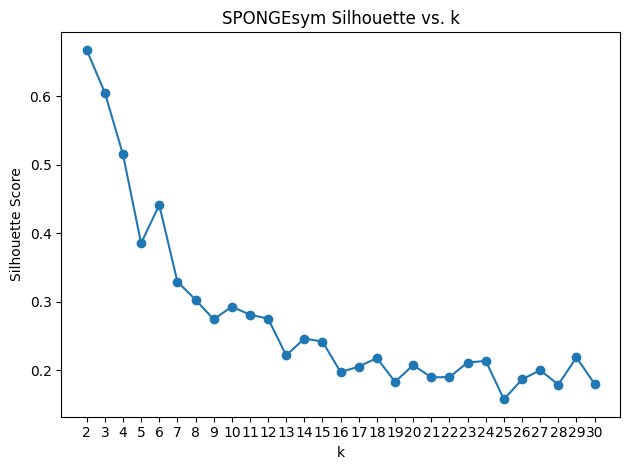

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

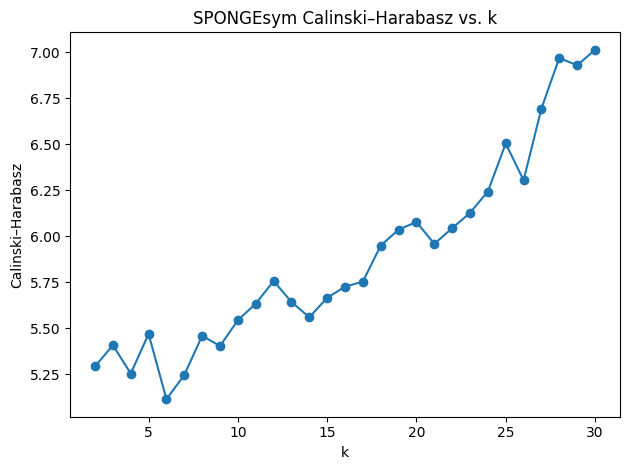

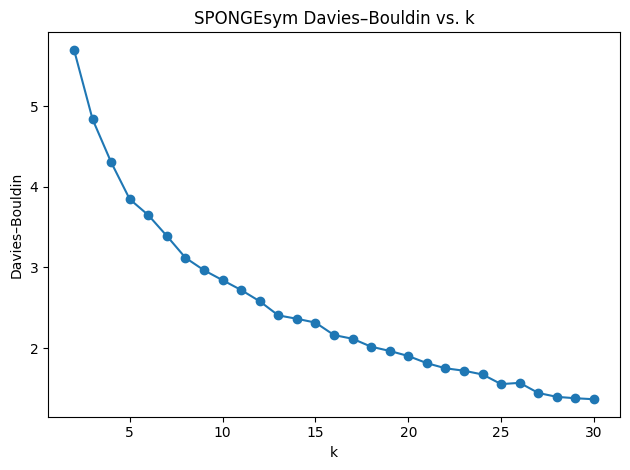

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

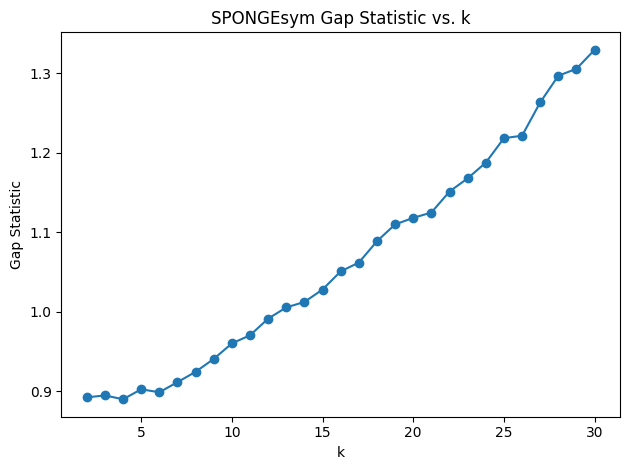

In [81]:
# -----------------------------------------------------------------------------
# SPONGE SYMMETRIC (SPONGEsym) K-SELECTION SCRIPT
#
# Implements k-selection for the symmetric SPONGE variant (SPONGEsym) on a
# -----------------------------------------------------------------------------

corr_array = sparse_corr.values 
N = corr_array.shape[0]

# ----------------------------------------------------------------------------
# PARAMETERS for SPONGEsym
# ----------------------------------------------------------------------------
tau_plus = 1.0
tau_minus = 1.0

# ----------------------------------------------------------------------------
# STEP 1: Build SPONGEsym operator via matrix square-root of denominator
#
# From Cucuringu et al., the asymmetric SPONGE uses:
#   M1 = L_plus + τ⁻ D_minus
#   M2 = L_minus + τ⁺ D_plus
# SPONGEsym forms the symmetric operator:
#   P = M2^{-1/2} M1 M2^{-1/2}
# where M2^{-1/2} = U2 diag(1/√λ₂) U2^T from M2’s eigendecomposition.
# ----------------------------------------------------------------------------

A_plus  = np.clip(corr_array,    a_min=0, a_max=None)
A_minus = np.clip(-corr_array,   a_min=0, a_max=None)

D_plus  = np.diag(A_plus.sum(axis=1))
D_minus = np.diag(A_minus.sum(axis=1))

L_plus  = D_plus - A_plus
L_minus = D_minus - A_minus

M1 = L_plus + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

eigvals_M2, eigvecs_M2 = eigh(M2)
inv_sqrt_vals = np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12))
M2_inv_sqrt = eigvecs_M2 @ inv_sqrt_vals @ eigvecs_M2.T

P = M2_inv_sqrt @ M1 @ M2_inv_sqrt

eigvals_sym, eigvecs_sym = eigh(P)

# ----------------------------------------------------------------------------
# STEP 2: Eigengap heuristic on SPONGEsym spectrum
# ----------------------------------------------------------------------------
eigval_limit = min(30, N)
vals = eigvals_sym[:eigval_limit]
gaps = vals[1:] - vals[:-1]
gap_idx = np.argmax(gaps[1:]) + 1  
k_eigengap = gap_idx + 1
print(f"SPONGEsym Eigengap suggests k = {k_eigengap} (gap = {gaps[gap_idx]:.4f})")

plt.figure(figsize=(8,5))
plt.plot(range(1, eigval_limit+1), vals, marker='o', label='SPONGEsym eigenvalues')
plt.axvline(k_eigengap, linestyle='--', color='red', label=f'select k={k_eigengap}')
plt.scatter(k_eigengap, vals[k_eigengap-1], color='red')
plt.annotate(f"gap={gaps[gap_idx]:.4f}", xy=(k_eigengap+0.5, vals[k_eigengap-1]))
plt.xlabel('Index i')
plt.ylabel('Eigenvalue λ_i')
plt.title('SPONGEsym Spectrum with Eigengap Selection')
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# STEP 3: Silhouette analysis on SPONGEsym embedding
# ----------------------------------------------------------------------------
max_k = 30
silhouette_scores = []
for k in range(2, max_k+1):
    # skip trivial eigenvector (index 0)
    U = eigvecs_sym[:, :k]
    U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)
    silhouette_scores.append(silhouette_score(U_norm, labels))

k_sil = np.arange(2, max_k+1)[np.argmax(silhouette_scores)]
print(f"SPONGEsym Silhouette suggests k = {k_sil}")

plt.figure()
plt.plot(range(2, max_k+1), silhouette_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('SPONGEsym Silhouette vs. k')
plt.xticks(range(2, max_k+1))
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# STEP 4: Calinski–Harabasz & Davies–Bouldin on fixed SPONGEsym embedding
# ----------------------------------------------------------------------------
d_max = 30
U_fixed = eigvecs_sym[:, 1:d_max+1]
U_fixed_norm = U_fixed / np.linalg.norm(U_fixed, axis=1, keepdims=True)

k_vals = list(range(2, max_k+1))
ch_scores = []
db_scores = []
for k in k_vals:
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_fixed_norm)
    ch_scores.append(calinski_harabasz_score(U_fixed_norm, labels))
    db_scores.append(davies_bouldin_score(U_fixed_norm, labels))

plt.figure()
plt.plot(k_vals, ch_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Calinski–Harabasz')
plt.title('SPONGEsym Calinski–Harabasz vs. k')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(k_vals, db_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Davies–Bouldin')
plt.title('SPONGEsym Davies–Bouldin vs. k')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# STEP 5: Gap statistic on SPONGEsym embedding
# ----------------------------------------------------------------------------
def compute_gap_statistic(data, k_max, n_refs=20):
    data_min = data.min(axis=0)
    data_max = data.max(axis=0)
    gaps = np.zeros(k_max-1)
    for idx, k in enumerate(range(2, k_max+1)):
        w_real = KMeans(n_clusters=k, random_state=0).fit(data).inertia_
        w_refs = []
        for _ in range(n_refs):
            rnd = np.random.rand(*data.shape)*(data_max-data_min)+data_min
            w_refs.append(KMeans(n_clusters=k, random_state=0).fit(rnd).inertia_)
        gaps[idx] = np.log(np.mean(w_refs)) - np.log(w_real)
    return gaps

gaps_vals = compute_gap_statistic(U_fixed_norm, k_max=max_k, n_refs=20)
plt.figure()
plt.plot(k_vals, gaps_vals, marker='o')
plt.xlabel('k')
plt.ylabel('Gap Statistic')
plt.title('SPONGEsym Gap Statistic vs. k')
plt.tight_layout()
plt.show()

/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/2259476147.py:26: RuntimeWarning: divide by zero encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/2259476147.py:26: RuntimeWarning: overflow encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/2259476147.py:26: RuntimeWarning: invalid value encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/2259476147.py:28: RuntimeWarning: divide by zero encountered in matmul
  P = inv_sqrt @ M1 @ inv_sqrt
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/2259476147.py:28: RuntimeWarning: overflow encountered in matmul
  P = inv_sqrt @ M1 @ inv_sqrt
/var/folders/8_/l7ym394s

Cluster Sizes:
 • Cluster 1: 104 assets
 • Cluster 2: 70 assets

Mean Correlation to ETH:
 • Cluster 1: 0.573
 • Cluster 2: 0.418

Mean intra-cluster correlation:
 • Cluster 1: 0.215
 • Cluster 2: 0.187



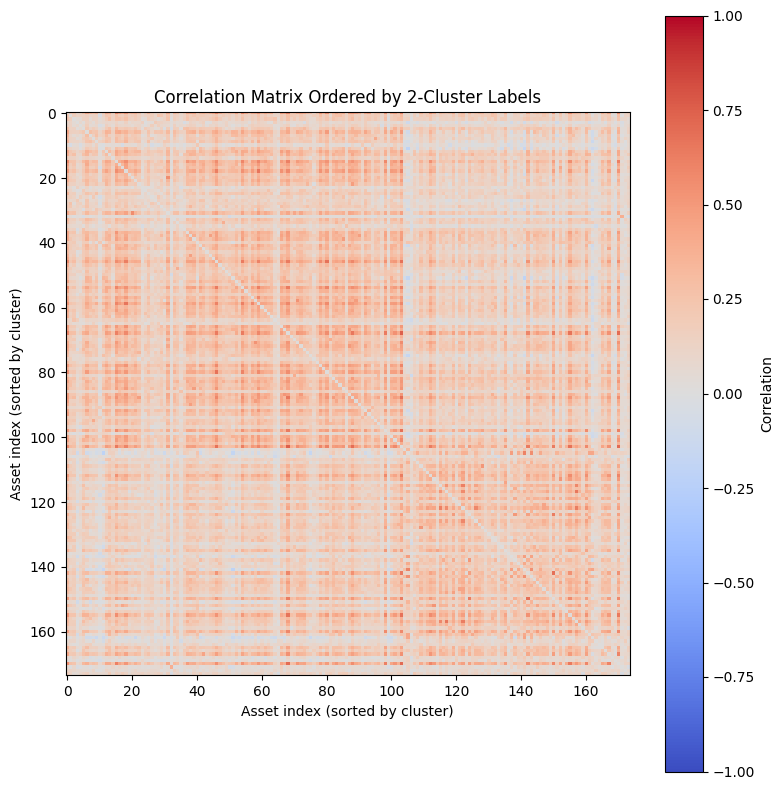

In [82]:
k = 2
tau_plus = 1.0
tau_minus = 1.0

eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy()
asset_logrets = log_returns_shared.to_numpy()

# --------------------------------------------------------------------------
# STEP A: SPONGEsym Embedding
#  Construct symmetric SPONGE operator P = M2^{-1/2} M1 M2^{-1/2}
# --------------------------------------------------------------------------

A_plus_df  = sparse_corr.clip(lower=0)
A_minus_df = (-sparse_corr).clip(lower=0)

D_plus  = np.diag(A_plus_df.sum(axis=1).values)
D_minus = np.diag(A_minus_df.sum(axis=1).values)

L_plus  = D_plus - A_plus_df.values
L_minus = D_minus - A_minus_df.values

M1 = L_plus + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

eigvals_M2, eigvecs_M2 = eigh(M2)
inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T

P = inv_sqrt @ M1 @ inv_sqrt

eigvals_sym, eigvecs_sym = eigh(P)

# --------------------------------------------------------------------------
# Build embedding using first k eigenvectors (nontrivial)
# --------------------------------------------------------------------------
U      = eigvecs_sym[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i, j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i, j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8, 8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/3900776506.py:26: RuntimeWarning: divide by zero encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/3900776506.py:26: RuntimeWarning: overflow encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/3900776506.py:26: RuntimeWarning: invalid value encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/3900776506.py:28: RuntimeWarning: divide by zero encountered in matmul
  P = inv_sqrt @ M1 @ inv_sqrt
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/3900776506.py:28: RuntimeWarning: overflow encountered in matmul
  P = inv_sqrt @ M1 @ inv_sqrt
/var/folders/8_/l7ym394s

Cluster Sizes:
 • Cluster 1: 89 assets
 • Cluster 2: 53 assets
 • Cluster 3: 32 assets

Mean Correlation to ETH:
 • Cluster 1: 0.579
 • Cluster 2: 0.506
 • Cluster 3: 0.330

Mean intra-cluster correlation:
 • Cluster 1: 0.212
 • Cluster 2: 0.269
 • Cluster 3: 0.157



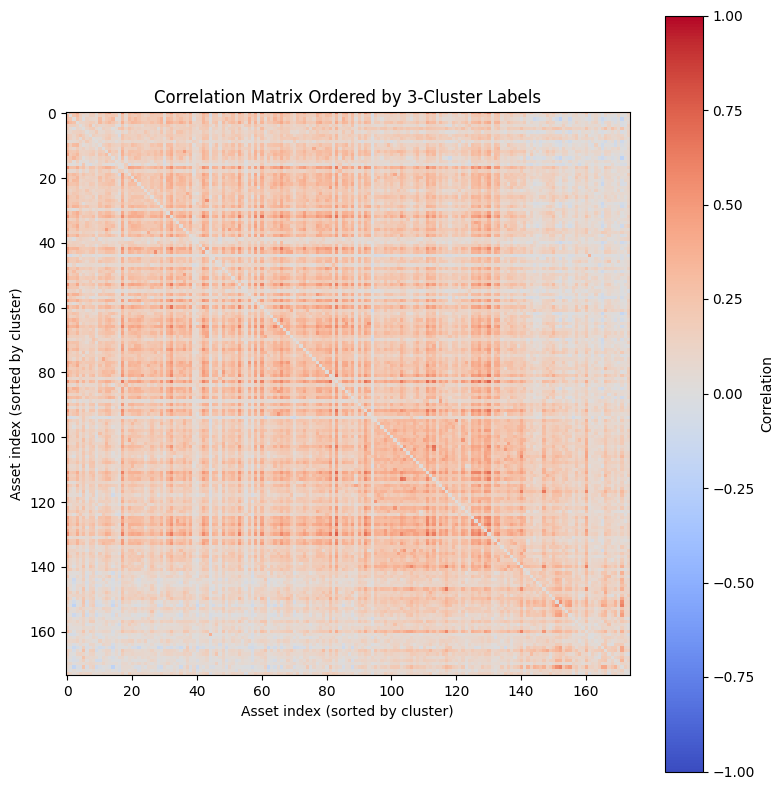

In [83]:
k = 3
tau_plus = 1.0
tau_minus = 1.0

eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy()  
asset_logrets = log_returns_shared.to_numpy()                

# --------------------------------------------------------------------------
# STEP A: SPONGEsym Embedding
#  Construct symmetric SPONGE operator P = M2^{-1/2} M1 M2^{-1/2}
# --------------------------------------------------------------------------

A_plus_df  = sparse_corr.clip(lower=0)
A_minus_df = (-sparse_corr).clip(lower=0)

D_plus  = np.diag(A_plus_df.sum(axis=1).values)
D_minus = np.diag(A_minus_df.sum(axis=1).values)

L_plus  = D_plus - A_plus_df.values
L_minus = D_minus - A_minus_df.values

M1 = L_plus + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

eigvals_M2, eigvecs_M2 = eigh(M2)
inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T

P = inv_sqrt @ M1 @ inv_sqrt

eigvals_sym, eigvecs_sym = eigh(P)

# --------------------------------------------------------------------------
# Build embedding using first k eigenvectors (nontrivial)
# --------------------------------------------------------------------------
U      = eigvecs_sym[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels_3 = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique_3, counts = np.unique(labels_3, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique_3, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique_3:
    members = np.where(labels_3 == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique_3:
    members = np.where(labels_3 == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i, j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i, j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels_3)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8, 8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

In [84]:
token_summary = pd.read_csv('data/token_summary.csv')
token_summary.set_index('symbol', inplace=True)
token_summary.head()

,circulating_supply,price_usd,market_cap_usd
symbol,,,
DGB,1.771598e+10,0.009832,1.741816e+08
DASH,1.227934e+07,23.742810,2.915461e+08
XVG,1.652195e+10,0.007502,1.239501e+08
XEM,9.000000e+09,0.009851,8.865895e+07
SC,5.602564e+10,0.003461,1.939043e+08


In [85]:
# 1. Compute ETH-to-asset correlations
if isinstance(eth_log_returns_shared, pd.DataFrame):
    eth_series = eth_log_returns_shared.iloc[:, 0]
else:
    eth_series = eth_log_returns_shared

# Align indices
common_idx = excess_log_returns.index.intersection(eth_series.index)
eth_series = eth_series.loc[common_idx]
excess = excess_log_returns.loc[common_idx]
# Drop '_returns' suffix for corr index matching
assets = [col.rsplit('_', 1)[0] for col in excess.columns]
excess.columns = assets

# Compute correlations
rho_eth = excess.corrwith(eth_series)

# 2. Variance of ρ→ETH per cluster
print("Variance of ρ→ETH per cluster:")
for cid in np.unique(labels_3):
    members = [assets[i] for i, lab in enumerate(labels_3) if lab == cid]
    var_val = rho_eth.loc[members].var()
    print(f" • Cluster {cid+1} (n={len(members)}): var = {var_val:.4f}")

# 3. Build feature summary for each cluster
rows = []
for cid in np.unique(labels_3):
    members = [assets[i] for i, lab in enumerate(labels_3) if lab == cid]
    
    # Volume columns have '_volumes' suffix
    vol_cols = [f"{asset}_volumes" for asset in members]
    vol_df = volumes[vol_cols]
    
    # Return cols: '{asset}_returns'
    ret_cols = [f"{asset}_returns" for asset in members]
    ret_df = excess_log_returns[ret_cols]
    # Align index for volatility
    ret_df = ret_df.loc[common_idx]
    
    # Token fundamentals
    ts = token_summary.loc[members]
    
    rows.append({
        'cluster':                 cid+1,
        'n_assets':                len(members),
        'var_rho_eth':             rho_eth.loc[members].var(),
        'mean_daily_volume':       vol_df.mean().mean(),
        'avg_excess_log_vol':      ret_df.std().mean(),
        'mean_price_usd':          ts['price_usd'].mean(),
        'mean_circ_supply':        ts['circulating_supply'].mean(),
        'mean_market_cap_usd':     ts['market_cap_usd'].mean(),
    })

summary_df = pd.DataFrame(rows)
summary_df.set_index('cluster', inplace=True)
summary_df

Variance of ρ→ETH per cluster:
 • Cluster 1 (n=89): var = 0.0090
 • Cluster 2 (n=53): var = 0.0086
 • Cluster 3 (n=32): var = 0.0361


,n_assets,var_rho_eth,mean_daily_volume,avg_excess_log_vol,mean_price_usd,mean_circ_supply,mean_market_cap_usd
cluster,,,,,,,
1,89,0.008978,2.294466e+07,0.050845,2.519689,4.424691e+18,1.412989e+08
2,53,0.008598,2.371478e+07,0.047394,107.124098,4.579882e+09,1.369798e+08
3,32,0.036143,4.992425e+06,0.055357,2.830685,1.077368e+10,1.345863e+08



--- Cluster 1: No-PC Removal Analysis (89 assets) ---


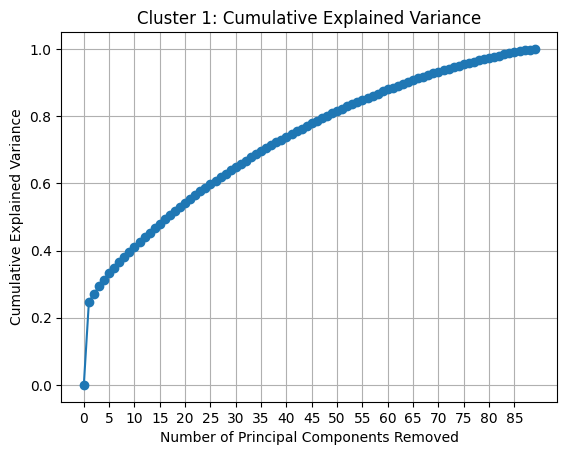

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


Top 10 positive z-scores (no PC removal):
GLMR_returns    2.277595
WILD_returns    0.704165
IOTX_returns    0.526862
XVG_returns     0.249501
ORDI_returns    0.199629
YGG_returns     0.196380
BAL_returns     0.139817
LQTY_returns    0.058213
XCH_returns     0.046552
BNT_returns     0.009666
Name: 2025-05-28, dtype: float64
Top 10 negative z-scores (no PC removal):
CFG_returns     -1.696211
LRC_returns     -1.297548
0x0_returns     -1.179684
HEART_returns   -1.151128
EDU_returns     -1.065782
CHR_returns     -1.055418
FIDA_returns    -0.991649
ORCA_returns    -0.965352
CHEX_returns    -0.951866
CGPT_returns    -0.951377
Name: 2025-05-28, dtype: float64

--- Cluster 2: No-PC Removal Analysis (53 assets) ---


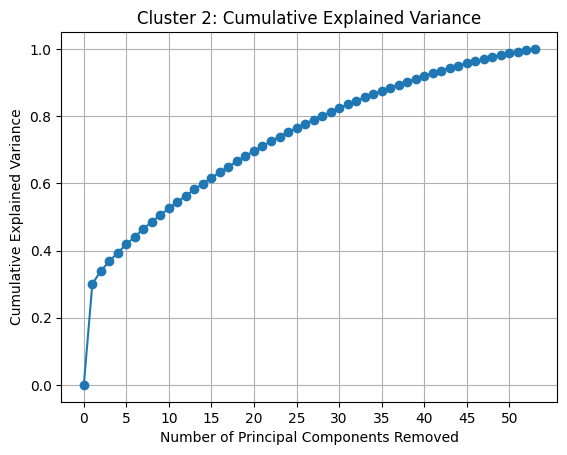

Top 10 positive z-scores (no PC removal):
MASK_returns    3.525367
LCX_returns     2.099409
SNT_returns     1.829932
ICX_returns     0.744298
HIVE_returns    0.307969
ARK_returns     0.107896
BORA_returns    0.102560
DAG_returns    -0.014711
ACT_returns    -0.086926
REQ_returns    -0.087056
Name: 2025-05-28, dtype: float64
Top 10 negative z-scores (no PC removal):
KEEP_returns    -5.340686
XEM_returns     -4.582049
AERGO_returns   -1.427570
AWE_returns     -0.998446
ARDR_returns    -0.862899
MTL_returns     -0.855381
BAT_returns     -0.847687
XNO_returns     -0.829072
TFUEL_returns   -0.783375
QTUM_returns    -0.718399
Name: 2025-05-28, dtype: float64


In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# We keep clusters 1 and 2 (labels 0 and 1 in zero-based `labels_3`)
keep_cids = [0, 1]

for cid in keep_cids:
    members = [assets[i] for i, lab in enumerate(labels_3) if lab == cid]
    print(f"\n--- Cluster {cid+1}: No-PC Removal Analysis ({len(members)} assets) ---")
    
    # 1. Extract and align returns
    ret_cols = [f"{m}_returns" for m in members]
    ret_df = excess_log_returns.loc[common_idx, ret_cols].dropna()
    
    # 2. Standardize returns (zero mean, unit variance)
    scaler = StandardScaler()
    ret_std = pd.DataFrame(
        scaler.fit_transform(ret_df),
        index=ret_df.index,
        columns=ret_df.columns
    )
    
    # 3. Fit PCA and compute cumulative explained variance including 0 PCs
    pca = PCA()
    pca.fit(ret_std)
    evr = pca.explained_variance_ratio_

    # Prepend zero for 0 PCs removed
    cum_evr = np.concatenate([[0.0], np.cumsum(evr)])
    pcs = np.arange(len(cum_evr))  # [0, 1, 2, ...]

    # 4. Plot cumulative explained variance with x-axis ticks every 5 PCs removed
    plt.figure()
    plt.plot(pcs, cum_evr, marker='o')
    plt.title(f"Cluster {cid+1}: Cumulative Explained Variance")
    plt.xlabel("Number of Principal Components Removed")
    plt.ylabel("Cumulative Explained Variance")
    max_pc = pcs[-1]
    xticks = np.arange(0, max_pc + 1, 5)
    plt.xticks(xticks)
    plt.grid(True)
    plt.show()
    
    # 5. Use standardized returns directly as residuals (no PCs removed)
    residuals_df = ret_std.copy()
    
    # 6. These are already z-scores by construction (mean=0, std=1)
    res_z = residuals_df
    
    # 7. Display top anomalies on most recent date
    latest = res_z.iloc[-1]
    print("Top 10 positive z-scores (no PC removal):")
    print(latest.nlargest(10))
    print("Top 10 negative z-scores (no PC removal):")
    print(latest.nsmallest(10))

In [87]:
# Keep clusters 1 & 2 (zero-based labels 0 and 1 in `labels_3`)
keep_cids = [0, 1]

for cid in keep_cids:
    members = [assets[i] for i, lab in enumerate(labels_3) if lab == cid]
    print(f"\n--- Cluster {cid+1}: PC1-Removed Residual Analysis ({len(members)} assets) ---")

    # 1. Extract and align returns
    ret_cols = [f"{m}_returns" for m in members]
    ret_df   = excess_log_returns.loc[common_idx, ret_cols].dropna()

    # 2. Standardize
    scaler   = StandardScaler()
    ret_std  = pd.DataFrame(
        scaler.fit_transform(ret_df),
        index=ret_df.index,
        columns=ret_df.columns
    )

    # 3. Fit PCA and get scores
    pca      = PCA()
    scores   = pca.fit_transform(ret_std)

    # 4. Reconstruct only the first principal component (PC1)
    pc1_scores   = scores[:, [0]]                # shape (n_days, 1)
    pc1_loadings = pca.components_[0:1, :]       # shape (1, n_assets)
    recon_pc1_std= pc1_scores @ pc1_loadings     # in standardized space
    recon_pc1    = scaler.inverse_transform(recon_pc1_std)

    # 5. Compute residuals (removing PC1) and z-score them
    residuals     = ret_df.values - recon_pc1
    residuals_df  = pd.DataFrame(residuals, index=ret_df.index, columns=ret_df.columns)
    res_z         = (residuals_df - residuals_df.mean()) / residuals_df.std()

    # 6. Print top/bottom 10 anomalies on the most recent date
    latest = res_z.iloc[-1]
    print("Top 10 positive residual z-scores after PC1 removal:")
    print(latest.nlargest(10))
    print("Top 10 negative residual z-scores after PC1 removal:")
    print(latest.nsmallest(10))


--- Cluster 1: PC1-Removed Residual Analysis (89 assets) ---
Top 10 positive residual z-scores after PC1 removal:
GLMR_returns    3.499787
IOTX_returns    1.133937
WILD_returns    0.919485
YGG_returns     0.748617
XVG_returns     0.599694
BAL_returns     0.560758
ORDI_returns    0.559773
ILV_returns     0.523984
SNX_returns     0.499958
LUNA_returns    0.469249
Name: 2025-05-28, dtype: float64
Top 10 negative residual z-scores after PC1 removal:
CFG_returns     -1.517132
LRC_returns     -1.065257
0x0_returns     -1.055428
HEART_returns   -1.012774
CHEX_returns    -0.833151
ORCA_returns    -0.786788
ACX_returns     -0.766750
EDU_returns     -0.741755
CHR_returns     -0.728798
CGPT_returns    -0.698483
Name: 2025-05-28, dtype: float64

--- Cluster 2: PC1-Removed Residual Analysis (53 assets) ---
Top 10 positive residual z-scores after PC1 removal:
MASK_returns    4.686763
SNT_returns     2.504058
LCX_returns     2.390766
ICX_returns     2.268642
HIVE_returns    0.813594
BORA_returns    

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3

Cluster Sizes:
 • Cluster 1: 26 assets
 • Cluster 2: 76 assets
 • Cluster 3: 46 assets
 • Cluster 4: 26 assets

Mean Correlation to ETH:
 • Cluster 1: 0.412
 • Cluster 2: 0.588
 • Cluster 3: 0.550
 • Cluster 4: 0.316

Mean intra-cluster correlation:
 • Cluster 1: 0.225
 • Cluster 2: 0.228
 • Cluster 3: 0.257
 • Cluster 4: 0.152



/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/4166992609.py:26: RuntimeWarning: divide by zero encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/4166992609.py:26: RuntimeWarning: overflow encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/4166992609.py:26: RuntimeWarning: invalid value encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/4166992609.py:28: RuntimeWarning: divide by zero encountered in matmul
  P = inv_sqrt @ M1 @ inv_sqrt
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/4166992609.py:28: RuntimeWarning: overflow encountered in matmul
  P = inv_sqrt @ M1 @ inv_sqrt
/var/folders/8_/l7ym394s

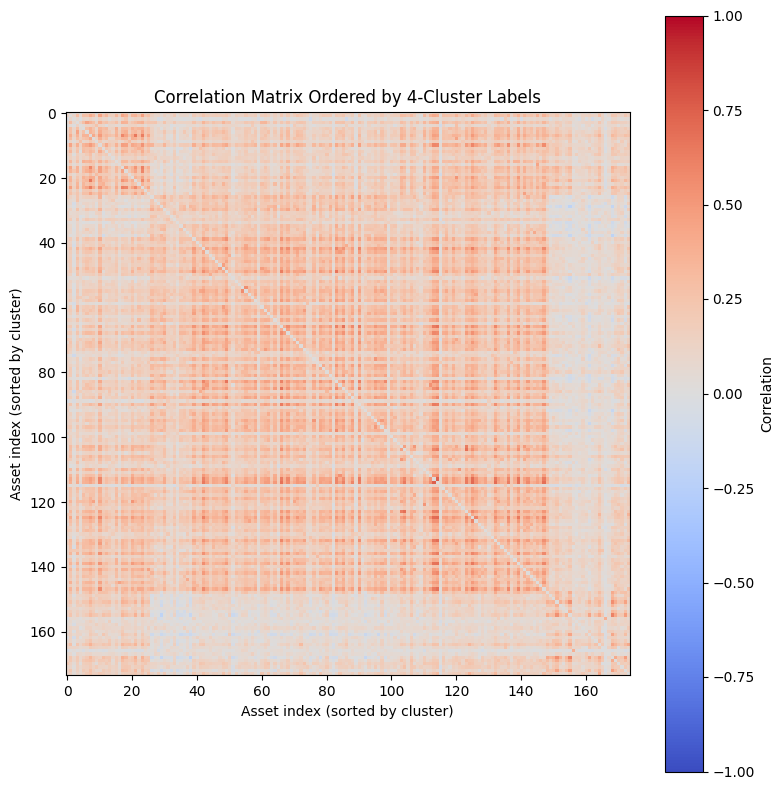

In [88]:
k = 4
tau_plus = 1.0
tau_minus = 1.0

eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy()  
asset_logrets = log_returns_shared.to_numpy()                

# --------------------------------------------------------------------------
# STEP A: SPONGEsym Embedding
#  Construct symmetric SPONGE operator P = M2^{-1/2} M1 M2^{-1/2}
# --------------------------------------------------------------------------

A_plus_df  = sparse_corr.clip(lower=0)
A_minus_df = (-sparse_corr).clip(lower=0)

D_plus  = np.diag(A_plus_df.sum(axis=1).values)
D_minus = np.diag(A_minus_df.sum(axis=1).values)

L_plus  = D_plus - A_plus_df.values
L_minus = D_minus - A_minus_df.values

M1 = L_plus + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

eigvals_M2, eigvecs_M2 = eigh(M2)
inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T

P = inv_sqrt @ M1 @ inv_sqrt

eigvals_sym, eigvecs_sym = eigh(P)

# --------------------------------------------------------------------------
# Build embedding using first k eigenvectors (nontrivial)
# --------------------------------------------------------------------------
U      = eigvecs_sym[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels_4 = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique_4, counts = np.unique(labels_4, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique_4, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique_4:
    members = np.where(labels_4 == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique_4:
    members = np.where(labels_4 == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i, j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i, j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels_4)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8, 8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()

In [89]:
# 1. Compute ETH-to-asset correlations
eth_series = eth_log_returns_shared.iloc[:, 0] if isinstance(eth_log_returns_shared, pd.DataFrame) else eth_log_returns_shared
common_idx = excess_log_returns.index.intersection(eth_series.index)
eth_series = eth_series.loc[common_idx]
excess = excess_log_returns.loc[common_idx]
assets = [col.rsplit('_', 1)[0] for col in excess.columns]
excess.columns = assets
rho_eth = excess.corrwith(eth_series)

# 3. Build summary for clusters 1, 2, 3, 4
rows = []
for cid in [0, 1, 2, 3]:
    members = [assets[i] for i, lab in enumerate(labels_4) if lab == cid]
    
    # Mean daily volume
    vol_cols = [f"{asset}_volumes" for asset in members]
    vol_df = volumes.loc[common_idx, vol_cols]
    
    # Excess log-return volatility
    ret_cols = [f"{asset}_returns" for asset in members]
    ret_df = excess_log_returns.loc[common_idx, ret_cols]
    
    # Token fundamentals
    ts = token_summary.loc[members]
    
    rows.append({
        'cluster':               cid + 1,
        'n_assets':              len(members),
        'var_rho_eth':           rho_eth.loc[members].var(),
        'mean_daily_volume':     vol_df.mean().mean(),
        'avg_excess_log_vol':    ret_df.std().mean(),
        'mean_price_usd':        ts['price_usd'].mean(),
        'mean_circ_supply':      ts['circulating_supply'].mean(),
        'mean_market_cap_usd':   ts['market_cap_usd'].mean(),
    })

summary_df = pd.DataFrame(rows).set_index('cluster')
summary_df

,n_assets,var_rho_eth,mean_daily_volume,avg_excess_log_vol,mean_price_usd,mean_circ_supply,mean_market_cap_usd
cluster,,,,,,,
1,26,0.012703,1.390475e+07,0.054908,0.154225,6.847762e+09,1.119324e+08
2,76,0.007875,2.461999e+07,0.048669,2.532937,2.174358e+15,1.419780e+08
3,46,0.005770,2.402888e+07,0.044456,124.053502,1.300681e+13,1.460063e+08
4,26,0.043243,4.644020e+06,0.062966,3.439895,1.513968e+19,1.432857e+08



--- Cluster 2: No-PC Removal Analysis (76 assets) ---


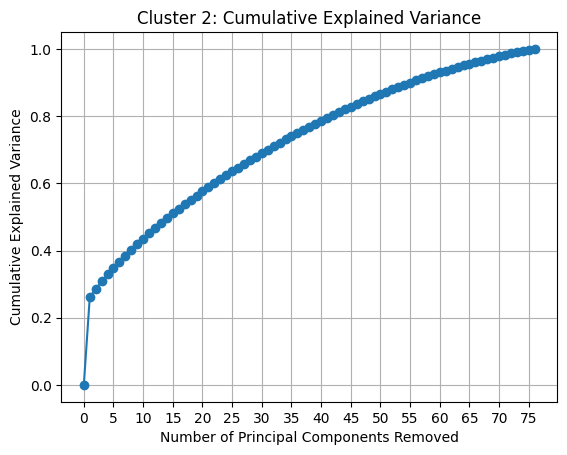

Top 10 positive z-scores (no PC removal):
GLMR_returns    2.277595
WILD_returns    0.704165
IOTX_returns    0.526862
XVG_returns     0.249501
ORDI_returns    0.199629
YGG_returns     0.196380
BAL_returns     0.139817
LQTY_returns    0.058213
XCH_returns     0.046552
ILV_returns     0.006687
Name: 2025-05-28, dtype: float64
Top 10 negative z-scores (no PC removal):
CFG_returns     -1.696211
LRC_returns     -1.297548
0x0_returns     -1.179684
EDU_returns     -1.065782
CHR_returns     -1.055418
FIDA_returns    -0.991649
ORCA_returns    -0.965352
CHEX_returns    -0.951866
CGPT_returns    -0.951377
CETUS_returns   -0.925660
Name: 2025-05-28, dtype: float64

--- Cluster 3: No-PC Removal Analysis (46 assets) ---


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


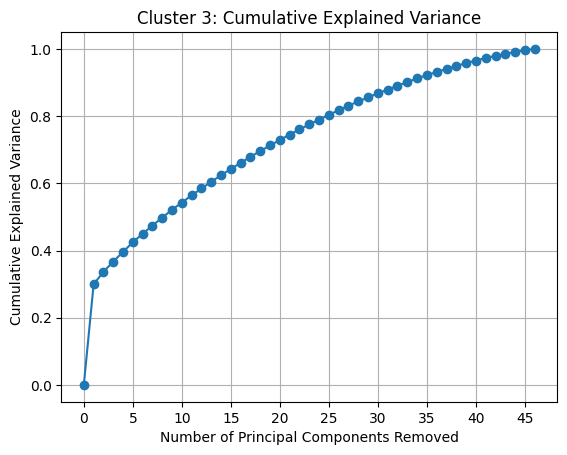

Top 10 positive z-scores (no PC removal):
MASK_returns    3.525367
SNT_returns     1.829932
ICX_returns     0.744298
ARK_returns     0.107896
BNT_returns     0.009666
DAG_returns    -0.014711
BONE_returns   -0.042395
REQ_returns    -0.087056
XVS_returns    -0.099036
ELON_returns   -0.128600
Name: 2025-05-28, dtype: float64
Top 10 negative z-scores (no PC removal):
XEM_returns     -4.582049
HEART_returns   -1.151128
BAT_returns     -0.847687
XNO_returns     -0.829072
TFUEL_returns   -0.783375
QTUM_returns    -0.718399
ZIL_returns     -0.703136
LSK_returns     -0.691260
STEEM_returns   -0.686195
POWR_returns    -0.642876
Name: 2025-05-28, dtype: float64


In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# We keep clusters 2 and 3 (labels 1 and 2 in zero-based `labels_4`)
keep_cids = [1, 2]

for cid in keep_cids:
    members = [assets[i] for i, lab in enumerate(labels_4) if lab == cid]
    print(f"\n--- Cluster {cid+1}: No-PC Removal Analysis ({len(members)} assets) ---")
    
    # 1. Extract and align returns
    ret_cols = [f"{m}_returns" for m in members]
    ret_df = excess_log_returns.loc[common_idx, ret_cols].dropna()
    
    # 2. Standardize returns (zero mean, unit variance)
    scaler = StandardScaler()
    ret_std = pd.DataFrame(
        scaler.fit_transform(ret_df),
        index=ret_df.index,
        columns=ret_df.columns
    )
    
    # 3. Fit PCA and compute cumulative explained variance including 0 PCs
    pca = PCA()
    pca.fit(ret_std)
    evr = pca.explained_variance_ratio_

    # Prepend zero for 0 PCs removed
    cum_evr = np.concatenate([[0.0], np.cumsum(evr)])
    pcs = np.arange(len(cum_evr))  # [0, 1, 2, ...]

    # 4. Plot cumulative explained variance with x-axis ticks every 5 PCs removed
    plt.figure()
    plt.plot(pcs, cum_evr, marker='o')
    plt.title(f"Cluster {cid+1}: Cumulative Explained Variance")
    plt.xlabel("Number of Principal Components Removed")
    plt.ylabel("Cumulative Explained Variance")
    max_pc = pcs[-1]
    xticks = np.arange(0, max_pc + 1, 5)
    plt.xticks(xticks)
    plt.grid(True)
    plt.show()
    
    # 5. Use standardized returns directly as residuals (no PCs removed)
    residuals_df = ret_std.copy()
    
    # 6. These are already z-scores by construction (mean=0, std=1)
    res_z = residuals_df
    
    # 7. Display top anomalies on most recent date
    latest = res_z.iloc[-1]
    print("Top 10 positive z-scores (no PC removal):")
    print(latest.nlargest(10))
    print("Top 10 negative z-scores (no PC removal):")
    print(latest.nsmallest(10))

In [91]:
# Keep clusters 2 & 3 (zero-based labels 1 and 2 in `labels_4`)
keep_cids = [1, 2]

for cid in keep_cids:
    members = [assets[i] for i, lab in enumerate(labels_4) if lab == cid]
    print(f"\n--- Cluster {cid+1}: PC1-Removed Residual Analysis ({len(members)} assets) ---")

    # 1. Extract and align returns
    ret_cols = [f"{m}_returns" for m in members]
    ret_df   = excess_log_returns.loc[common_idx, ret_cols].dropna()

    # 2. Standardize
    scaler   = StandardScaler()
    ret_std  = pd.DataFrame(
        scaler.fit_transform(ret_df),
        index=ret_df.index,
        columns=ret_df.columns
    )

    # 3. Fit PCA and get scores
    pca      = PCA()
    scores   = pca.fit_transform(ret_std)

    # 4. Reconstruct only the first principal component (PC1)
    pc1_scores   = scores[:, [0]]                # shape (n_days, 1)
    pc1_loadings = pca.components_[0:1, :]       # shape (1, n_assets)
    recon_pc1_std= pc1_scores @ pc1_loadings     # in standardized space
    recon_pc1    = scaler.inverse_transform(recon_pc1_std)

    # 5. Compute residuals (removing PC1) and z-score them
    residuals     = ret_df.values - recon_pc1
    residuals_df  = pd.DataFrame(residuals, index=ret_df.index, columns=ret_df.columns)
    res_z         = (residuals_df - residuals_df.mean()) / residuals_df.std()

    # 6. Print top/bottom 10 anomalies on the most recent date
    latest = res_z.iloc[-1]
    print("Top 10 positive residual z-scores after PC1 removal:")
    print(latest.nlargest(10))
    print("Top 10 negative residual z-scores after PC1 removal:")
    print(latest.nsmallest(10))


--- Cluster 2: PC1-Removed Residual Analysis (76 assets) ---
Top 10 positive residual z-scores after PC1 removal:
GLMR_returns    3.499127
IOTX_returns    1.131018
WILD_returns    0.920936
YGG_returns     0.751641
XVG_returns     0.587680
ORDI_returns    0.566088
BAL_returns     0.557112
ILV_returns     0.532758
SNX_returns     0.500081
LUNA_returns    0.466901
Name: 2025-05-28, dtype: float64
Top 10 negative residual z-scores after PC1 removal:
CFG_returns    -1.521653
LRC_returns    -1.069751
0x0_returns    -1.054123
CHEX_returns   -0.832076
ORCA_returns   -0.784069
ACX_returns    -0.766225
EDU_returns    -0.746201
CHR_returns    -0.733850
CGPT_returns   -0.698574
COW_returns    -0.686776
Name: 2025-05-28, dtype: float64

--- Cluster 3: PC1-Removed Residual Analysis (46 assets) ---
Top 10 positive residual z-scores after PC1 removal:
MASK_returns    4.681596
SNT_returns     2.416819
ICX_returns     2.163017
ARK_returns     0.460836
XVS_returns     0.250477
REQ_returns     0.247122
B

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3

Cluster Sizes:
 • Cluster 1: 47 assets
 • Cluster 2: 36 assets
 • Cluster 3: 41 assets
 • Cluster 4: 24 assets
 • Cluster 5: 26 assets

Mean Correlation to ETH:
 • Cluster 1: 0.588
 • Cluster 2: 0.564
 • Cluster 3: 0.540
 • Cluster 4: 0.321
 • Cluster 5: 0.427

Mean intra-cluster correlation:
 • Cluster 1: 0.200
 • Cluster 2: 0.235
 • Cluster 3: 0.267
 • Cluster 4: 0.172
 • Cluster 5: 0.249



/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/885653665.py:26: RuntimeWarning: divide by zero encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/885653665.py:26: RuntimeWarning: overflow encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/885653665.py:26: RuntimeWarning: invalid value encountered in matmul
  inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/885653665.py:28: RuntimeWarning: divide by zero encountered in matmul
  P = inv_sqrt @ M1 @ inv_sqrt
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_2023/885653665.py:28: RuntimeWarning: overflow encountered in matmul
  P = inv_sqrt @ M1 @ inv_sqrt
/var/folders/8_/l7ym394s7wzd2

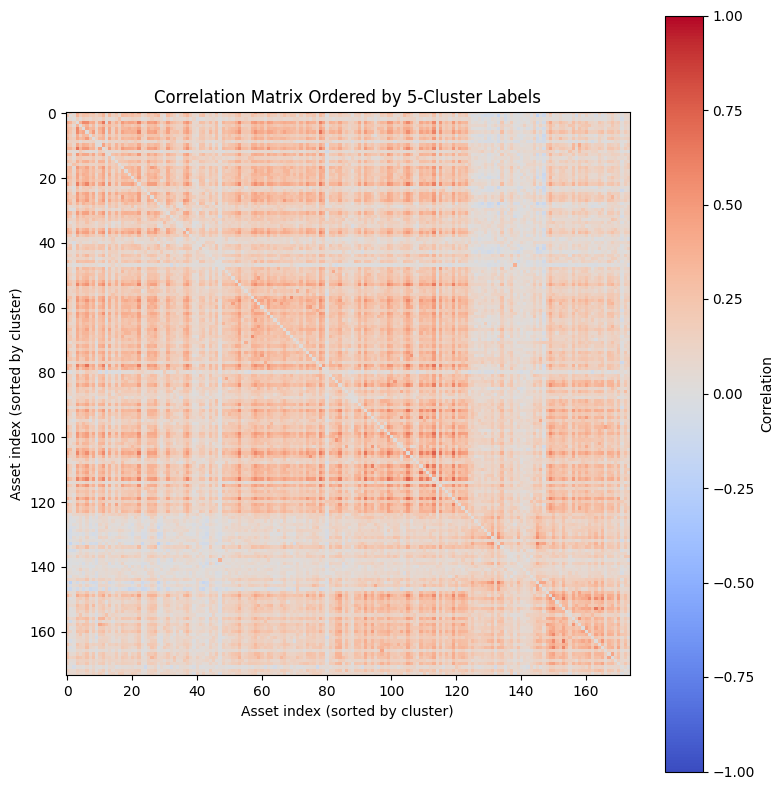

In [92]:
k = 5
tau_plus = 1.0
tau_minus = 1.0

eth_logrets   = eth_log_returns_shared.iloc[:, 0].to_numpy()  
asset_logrets = log_returns_shared.to_numpy()                

# --------------------------------------------------------------------------
# STEP A: SPONGEsym Embedding
#  Construct symmetric SPONGE operator P = M2^{-1/2} M1 M2^{-1/2}
# --------------------------------------------------------------------------

A_plus_df  = sparse_corr.clip(lower=0)
A_minus_df = (-sparse_corr).clip(lower=0)

D_plus  = np.diag(A_plus_df.sum(axis=1).values)
D_minus = np.diag(A_minus_df.sum(axis=1).values)

L_plus  = D_plus - A_plus_df.values
L_minus = D_minus - A_minus_df.values

M1 = L_plus + tau_minus * D_minus
M2 = L_minus + tau_plus  * D_plus

eigvals_M2, eigvecs_M2 = eigh(M2)
inv_sqrt = eigvecs_M2 @ np.diag(1.0 / np.sqrt(eigvals_M2 + 1e-12)) @ eigvecs_M2.T

P = inv_sqrt @ M1 @ inv_sqrt

eigvals_sym, eigvecs_sym = eigh(P)

# --------------------------------------------------------------------------
# Build embedding using first k eigenvectors (nontrivial)
# --------------------------------------------------------------------------
U      = eigvecs_sym[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

labels = KMeans(n_clusters=k, random_state=0).fit_predict(U_norm)

# --------------------------------------------------------------------------
# METHOD 1: Cluster sizes
# --------------------------------------------------------------------------
unique, counts = np.unique(labels, return_counts=True)
print("Cluster Sizes:")
for cid, cnt in zip(unique, counts):
    print(f" • Cluster {cid+1}: {cnt} assets")
print()

# --------------------------------------------------------------------------
# METHOD 2: Mean correlation to ETH
# --------------------------------------------------------------------------
corr_to_eth = np.array([
    np.corrcoef(eth_logrets, asset_logrets[:, i])[0, 1]
    for i in range(asset_logrets.shape[1])
])
print("Mean Correlation to ETH:")
for cid in unique:
    members = np.where(labels == cid)[0]
    print(f" • Cluster {cid+1}: {corr_to_eth[members].mean():.3f}")
print()

# --------------------------------------------------------------------------
# METHOD 3: Intra-cluster cohesiveness
# --------------------------------------------------------------------------
print("Mean intra-cluster correlation:")
for cid in unique:
    members = np.where(labels == cid)[0]
    subcorr = corr.iloc[members, members]
    M = subcorr.values
    if M.shape[0] > 1:
        i, j = np.triu_indices(M.shape[0], k=1)
        print(f" • Cluster {cid+1}: {M[i, j].mean():.3f}")
    else:
        print(f" • Cluster {cid+1}: n/a (singleton)")
print()

# --------------------------------------------------------------------------
# METHOD 4: Heatmap of reordered correlation matrix
# --------------------------------------------------------------------------
order = np.argsort(labels)
corr_reordered = corr.iloc[order, order]

plt.figure(figsize=(8, 8))
plt.imshow(corr_reordered, vmin=-1, vmax=1, cmap='coolwarm', aspect='equal')
plt.colorbar(label='Correlation')
plt.title(f'Correlation Matrix Ordered by {k}-Cluster Labels')
plt.xlabel('Asset index (sorted by cluster)')
plt.ylabel('Asset index (sorted by cluster)')
plt.tight_layout()
plt.show()